# Analyse statistique de la température et de l'irradiation solaire — Région de Benguerir
## Extraction des périodes représentatives — Approche statistique rigoureuse

**Objectif :** Déterminer statistiquement les périodes représentatives à partir des données horaires de **température (T2M)** et d'**irradiation solaire (ALLSKY_SFC_SW_DWN)** pour la région de Benguerir, Maroc.

**Données :** NASA POWER — 2001 à 2025 (données horaires)

**Méthodes utilisées :**
1. Chargement, nettoyage et traitement des valeurs manquantes (NaN fin 2025)
2. Analyse exploratoire (EDA)
3. Tests de stationnarité (ADF + KPSS)
4. Test de Ljung-Box — validation statistique des cycles
5. Analyse spectrale — quantification des fréquences dominantes
6. Régimes thermiques / d'irradiation — test de Kruskal-Wallis + post-hoc Mann-Whitney
7. Saisonnalité mensuelle — test non-paramétrique
8. Décomposition STL
9. PCA des profils journaliers
10. Clustering — validation multi-critères (Silhouette, Davies-Bouldin, Calinski-Harabasz)
11. Extraction et validation quantitative des journées représentatives (RMSE, R²)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from scipy import stats
from scipy.signal import periodogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
COLORS = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800','#795548','#607D8B']


## 1. Chargement et préparation des données

Les données proviennent de NASA POWER pour la région de Benguerir (Maroc).  
- **T2M** : Température à 2 mètres (°C)  
- **ALLSKY** : Irradiation solaire sur surface horizontale — All Sky (W/m²)

**Note :** Des valeurs NaN sont attendues dans ALLSKY pour les derniers mois de 2025 (novembre et décembre). Nous les traiterons par interpolation ou exclusion selon le contexte.


In [2]:
df = pd.read_csv("data_horaire.csv")
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime")

# Renommage clair
df = df.rename(columns={"T2M": "T2M", "ALLSKY": "ALLSKY"})

# Ajout de colonnes temporelles
df["month"] = df.index.month
df["hour"]  = df.index.hour
df["dow"]   = df.index.dayofweek
df["year"]  = df.index.year

# ── Diagnostic des valeurs manquantes ────────────────────────────
print("="*60)
print("DIAGNOSTIC DES DONNÉES")
print("="*60)
print(f"Période      : {df.index.min().date()} → {df.index.max().date()}")
print(f"Nb heures    : {len(df):,}")
print(f"T2M   — NaN  : {df['T2M'].isna().sum()}")
print(f"ALLSKY — NaN : {df['ALLSKY'].isna().sum()}")
print()

# Détail NaN par mois pour 2025
nan_2025 = df[df["year"]==2025].groupby("month")["ALLSKY"].apply(lambda x: x.isna().sum())
print("NaN ALLSKY par mois (2025) :")
for m, n in nan_2025.items():
    if n > 0:
        print(f"  Mois {m:02d} : {n} valeurs manquantes")

# ── Traitement des NaN ───────────────────────────────────────────
# Interpolation linéaire pour les petits gaps, 
# suppression des mois avec trop de NaN (décembre 2025 = 100% NaN)
df["ALLSKY"] = df["ALLSKY"].interpolate(method="linear", limit=48)
nan_after = df["ALLSKY"].isna().sum()
print(f"\nAprès interpolation (limit=48h) : {nan_after} NaN restants")
print("→ Les NaN restants (décembre 2025) seront exclus des analyses ALLSKY")

print()
print("Statistiques descriptives — T2M (°C) :")
print(df["T2M"].describe().round(2))
print()
print("Statistiques descriptives — ALLSKY (W/m²) :")
print(df["ALLSKY"].describe().round(2))


DIAGNOSTIC DES DONNÉES
Période      : 2001-01-01 → 2025-12-31
Nb heures    : 219,144
T2M   — NaN  : 0
ALLSKY — NaN : 762

NaN ALLSKY par mois (2025) :
  Mois 11 : 18 valeurs manquantes
  Mois 12 : 744 valeurs manquantes

Après interpolation (limit=48h) : 714 NaN restants
→ Les NaN restants (décembre 2025) seront exclus des analyses ALLSKY

Statistiques descriptives — T2M (°C) :
count    219144.00
mean         19.89
std           8.54
min          -3.35
25%          13.20
50%          18.94
75%          25.40
max          47.51
Name: T2M, dtype: float64

Statistiques descriptives — ALLSKY (W/m²) :
count    218430.00
mean        233.95
std         312.90
min           0.00
25%           0.00
50%           9.32
75%         464.25
max        1065.62
Name: ALLSKY, dtype: float64


## 2. Analyse exploratoire des données (EDA)


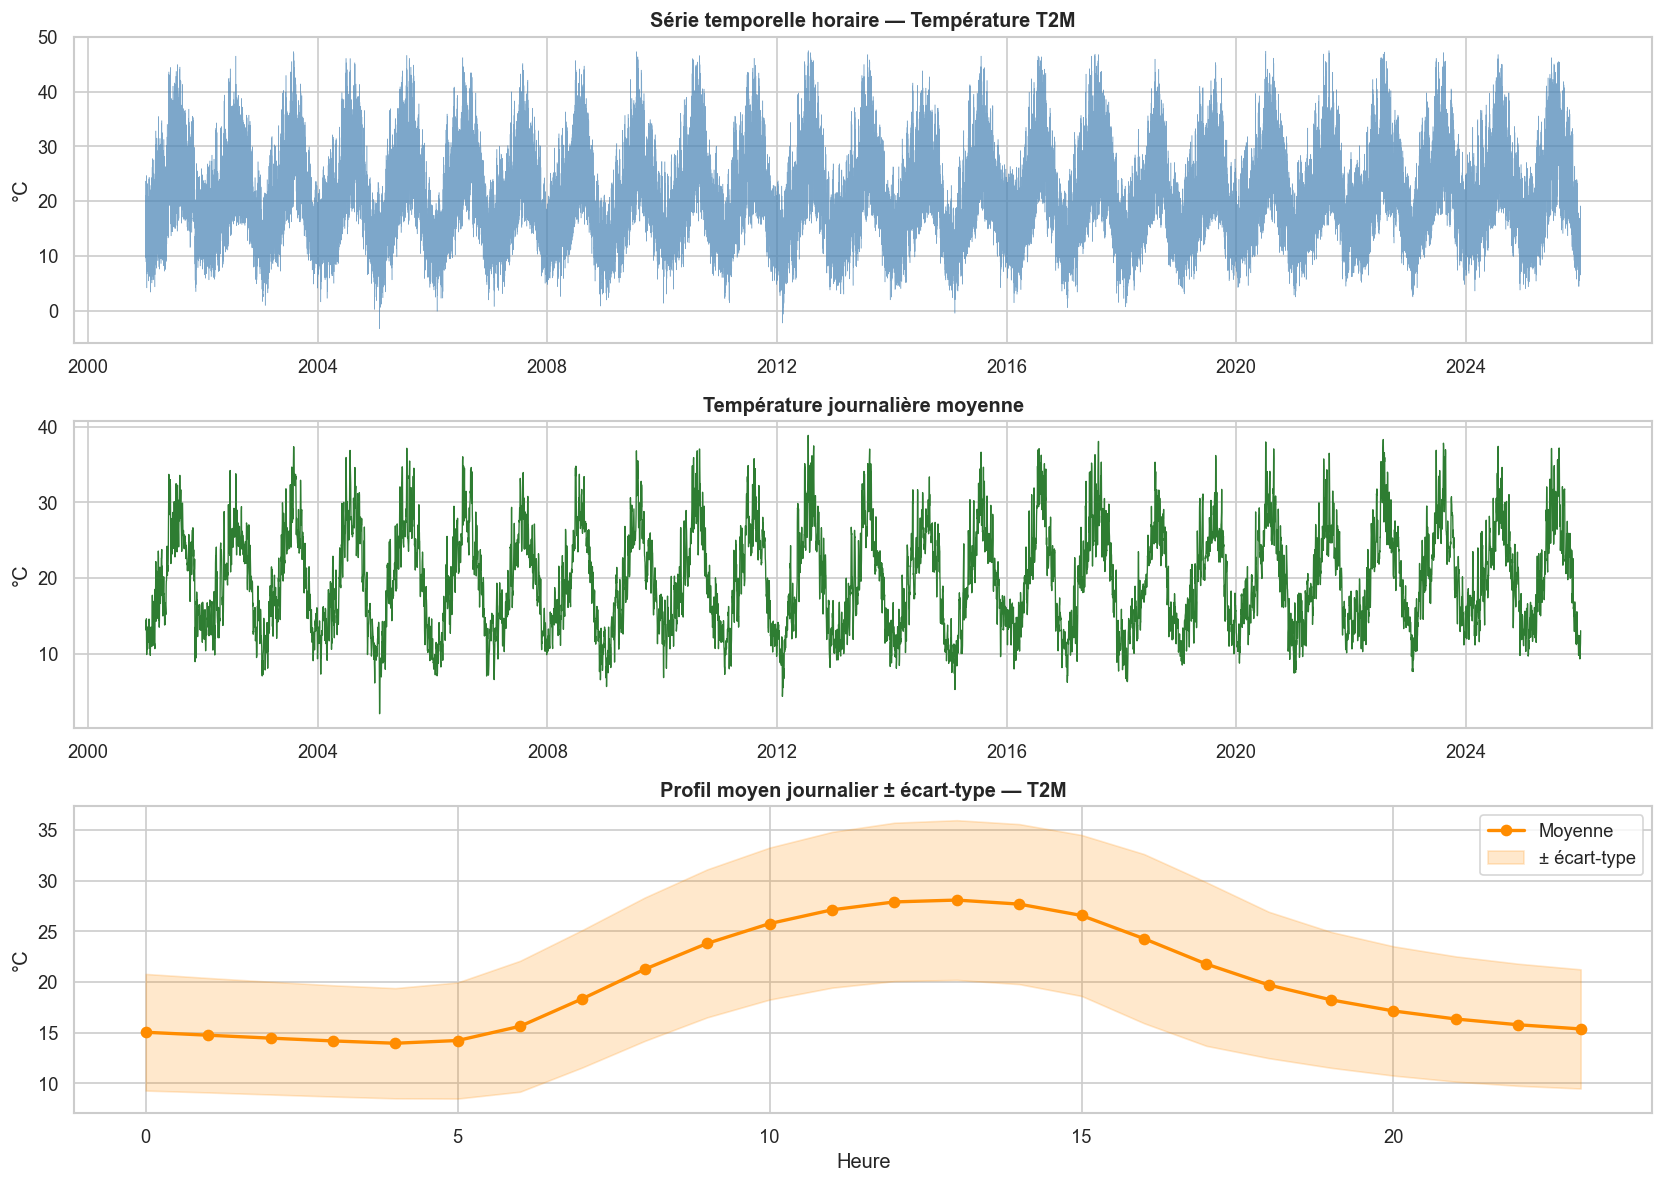

In [3]:
# ═══════════════════════════════════════════════════════════════════
# 2.1 — TEMPÉRATURE T2M
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df.index, df["T2M"], lw=0.3, color="steelblue", alpha=0.7)
axes[0].set_title("Série temporelle horaire — Température T2M", fontweight="bold")
axes[0].set_ylabel("°C")

daily_t = df["T2M"].resample("D").mean()
axes[1].plot(daily_t, color="#2e7d32", lw=0.8)
axes[1].set_title("Température journalière moyenne", fontweight="bold")
axes[1].set_ylabel("°C")

hourly_t     = df.groupby("hour")["T2M"].mean()
hourly_t_std = df.groupby("hour")["T2M"].std()
axes[2].plot(hourly_t, marker="o", color="darkorange", lw=2, label="Moyenne")
axes[2].fill_between(hourly_t.index, hourly_t - hourly_t_std, hourly_t + hourly_t_std,
                     alpha=0.2, color="darkorange", label="± écart-type")
axes[2].set_title("Profil moyen journalier ± écart-type — T2M", fontweight="bold")
axes[2].set_xlabel("Heure"); axes[2].set_ylabel("°C"); axes[2].legend()

plt.tight_layout(); plt.show()


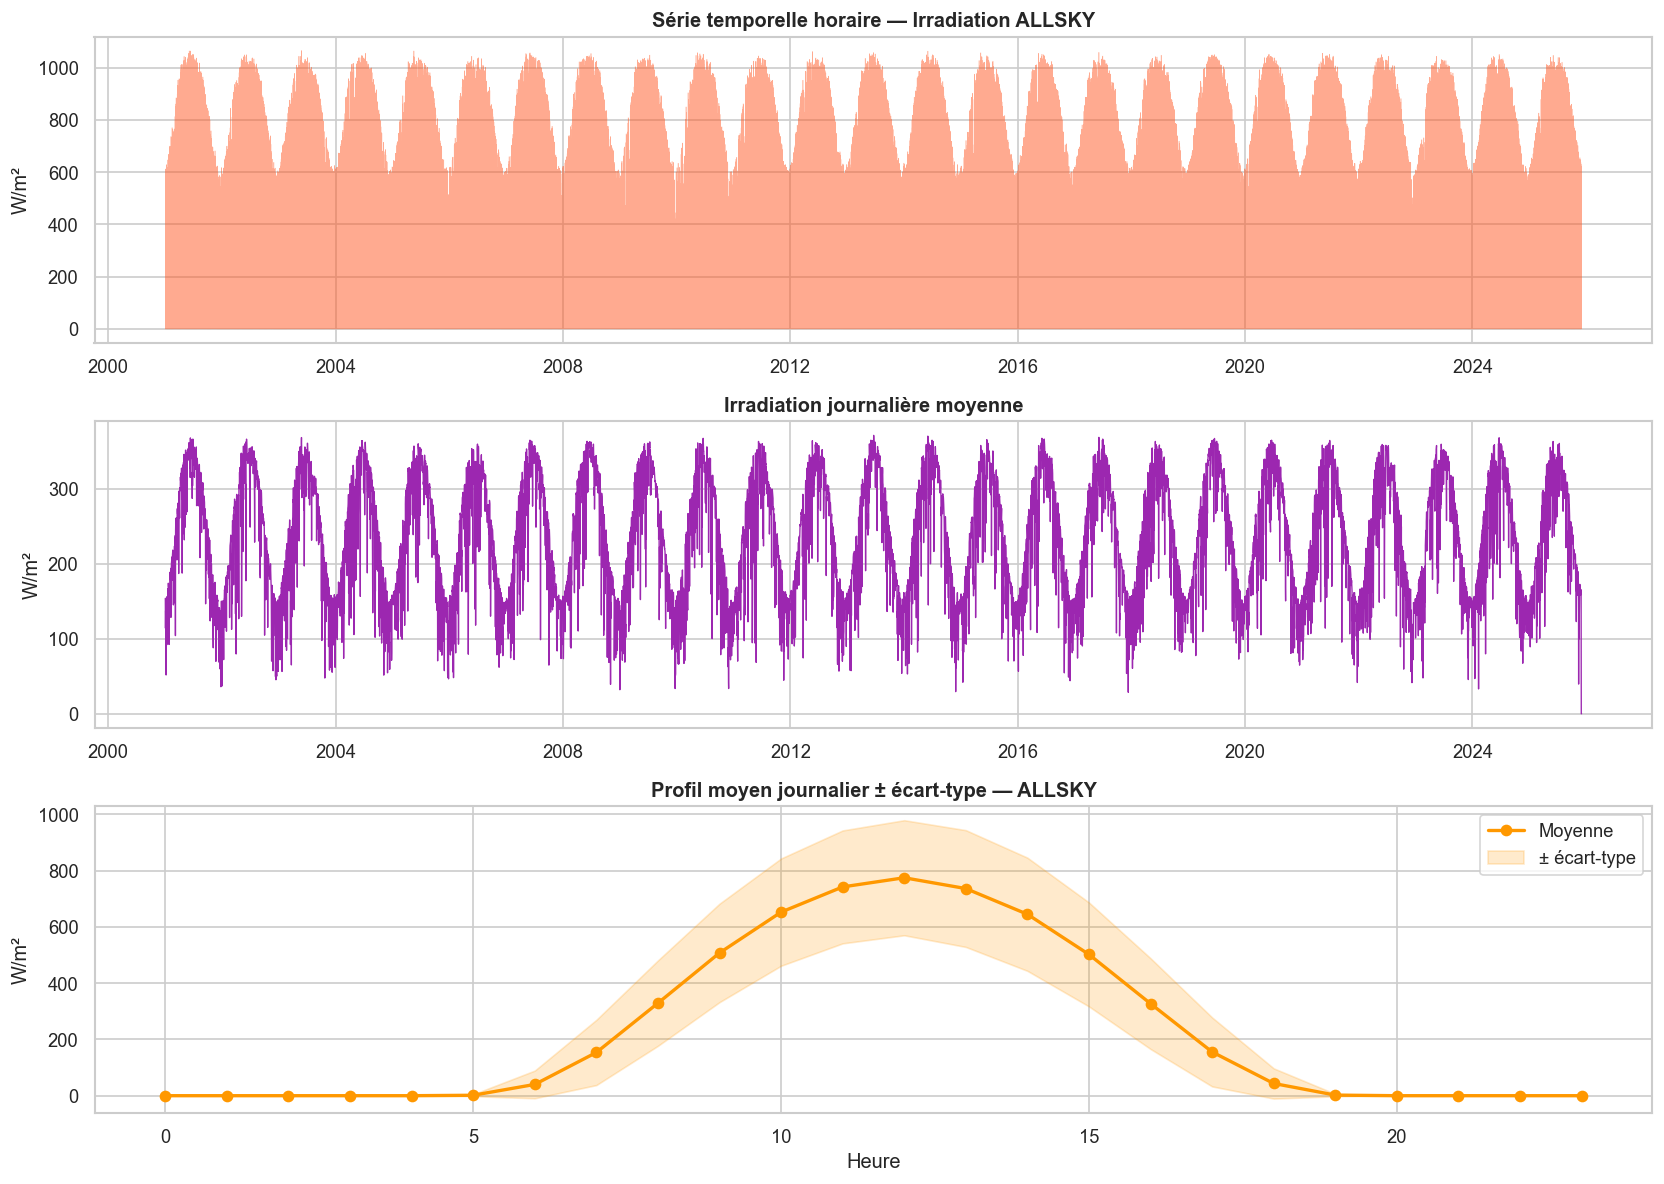

In [4]:
# ═══════════════════════════════════════════════════════════════════
# 2.2 — IRRADIATION SOLAIRE ALLSKY
# ═══════════════════════════════════════════════════════════════════
df_solar = df["ALLSKY"].dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df_solar.index, df_solar, lw=0.3, color="#FF5722", alpha=0.5)
axes[0].set_title("Série temporelle horaire — Irradiation ALLSKY", fontweight="bold")
axes[0].set_ylabel("W/m²")

daily_s = df_solar.resample("D").mean()
axes[1].plot(daily_s, color="#9C27B0", lw=0.8)
axes[1].set_title("Irradiation journalière moyenne", fontweight="bold")
axes[1].set_ylabel("W/m²")

hourly_s     = df.groupby("hour")["ALLSKY"].mean()
hourly_s_std = df.groupby("hour")["ALLSKY"].std()
axes[2].plot(hourly_s, marker="o", color="#FF9800", lw=2, label="Moyenne")
axes[2].fill_between(hourly_s.index, hourly_s - hourly_s_std, hourly_s + hourly_s_std,
                     alpha=0.2, color="#FF9800", label="± écart-type")
axes[2].set_title("Profil moyen journalier ± écart-type — ALLSKY", fontweight="bold")
axes[2].set_xlabel("Heure"); axes[2].set_ylabel("W/m²"); axes[2].legend()

plt.tight_layout(); plt.show()


## 3. Tests de stationnarité

Avant toute analyse spectrale ou de décomposition, il faut vérifier la stationnarité de la série.

- **ADF (Augmented Dickey-Fuller)** — H₀ : la série est non-stationnaire (racine unitaire)
- **KPSS** — H₀ : la série est stationnaire autour d'une tendance

L'interprétation conjointe des deux tests permet de distinguer : stationnarité stricte, non-stationnarité, ou stationnarité avec tendance.


In [5]:
def run_stationarity_tests(series, name):
    """Exécute les tests ADF et KPSS et affiche les résultats."""
    series_clean = series.dropna()
    
    # ── Test ADF ──
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series_clean, autolag="AIC")
    print("="*60)
    print(f"ADF Test — {name}  (H0 = série NON-STATIONNAIRE)")
    print("="*60)
    print(f"  Statistique ADF : {adf_stat:.4f}")
    print(f"  p-value         : {adf_p:.2e}  →", 
          "Rejet H0 ✓ — STATIONNAIRE" if adf_p < 0.05 else "Non rejet H0")
    for k, v in adf_crit.items():
        flag = "✓" if adf_stat < v else " "
        print(f"  Valeur critique {k}: {v:.4f}  {flag}")
    
    # ── Test KPSS ──
    kpss_stat, kpss_p, _, kpss_crit = kpss(series_clean, regression="ct", nlags="auto")
    print()
    print("="*60)
    print(f"KPSS Test — {name}  (H0 = série STATIONNAIRE autour d'une tendance)")
    print("="*60)
    print(f"  Statistique KPSS: {kpss_stat:.4f}")
    print(f"  p-value         : {kpss_p:.4f}  →", 
          "Rejet H0 — composante tendancielle" if kpss_p < 0.05 
          else "Non rejet H0 ✓ — stationnaire")
    print()

# Tests pour T2M
run_stationarity_tests(df["T2M"], "Température T2M (°C)")

# Tests pour ALLSKY
run_stationarity_tests(df["ALLSKY"], "Irradiation ALLSKY (W/m²)")

print("CONCLUSION :")
print("  Si ADF rejette et KPSS ne rejette pas → série stationnaire ✓")
print("  Si ADF rejette et KPSS rejette → stationnaire avec tendance saisonnière")
print("  → La décomposition STL est appropriée dans les deux cas.")


ADF Test — Température T2M (°C)  (H0 = série NON-STATIONNAIRE)
  Statistique ADF : -13.2551
  p-value         : 8.62e-25  → Rejet H0 ✓ — STATIONNAIRE
  Valeur critique 1%: -3.4304  ✓
  Valeur critique 5%: -2.8616  ✓
  Valeur critique 10%: -2.5668  ✓

KPSS Test — Température T2M (°C)  (H0 = série STATIONNAIRE autour d'une tendance)
  Statistique KPSS: 0.1116
  p-value         : 0.1000  → Non rejet H0 ✓ — stationnaire



C:\Users\Oumaima\AppData\Local\Temp\ipykernel_3572\3169841899.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series_clean, regression="ct", nlags="auto")


ADF Test — Irradiation ALLSKY (W/m²)  (H0 = série NON-STATIONNAIRE)
  Statistique ADF : -14.5969
  p-value         : 4.23e-27  → Rejet H0 ✓ — STATIONNAIRE
  Valeur critique 1%: -3.4304  ✓
  Valeur critique 5%: -2.8616  ✓
  Valeur critique 10%: -2.5668  ✓

KPSS Test — Irradiation ALLSKY (W/m²)  (H0 = série STATIONNAIRE autour d'une tendance)
  Statistique KPSS: 0.0139
  p-value         : 0.1000  → Non rejet H0 ✓ — stationnaire

CONCLUSION :
  Si ADF rejette et KPSS ne rejette pas → série stationnaire ✓
  Si ADF rejette et KPSS rejette → stationnaire avec tendance saisonnière
  → La décomposition STL est appropriée dans les deux cas.


C:\Users\Oumaima\AppData\Local\Temp\ipykernel_3572\3169841899.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(series_clean, regression="ct", nlags="auto")


## 4. Test de Ljung-Box — Validation statistique des cycles

L'ACF visuelle ne suffit pas : le **test de Ljung-Box** permet de tester formellement
si l'autocorrélation aux lags sélectionnés est statistiquement significative.

**H₀ :** Les autocorrélations jusqu'au lag *k* sont nulles (bruit blanc)


Test de Ljung-Box — Température T2M
  (H0 = pas d'autocorrélation jusqu'au lag k)
                   Lag |       Q-stat |      p-value | Décision
  ------------------------------------------------------------
      24h (journalier) |    2204165.2 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF
         48h (2 jours) |    4198954.4 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF
   168h (hebdomadaire) |   12551069.4 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF
     336h (2 semaines) |   22965225.0 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF

→ Les cycles à 24h et 168h sont statistiquement prouvés (p ≪ 0.001)


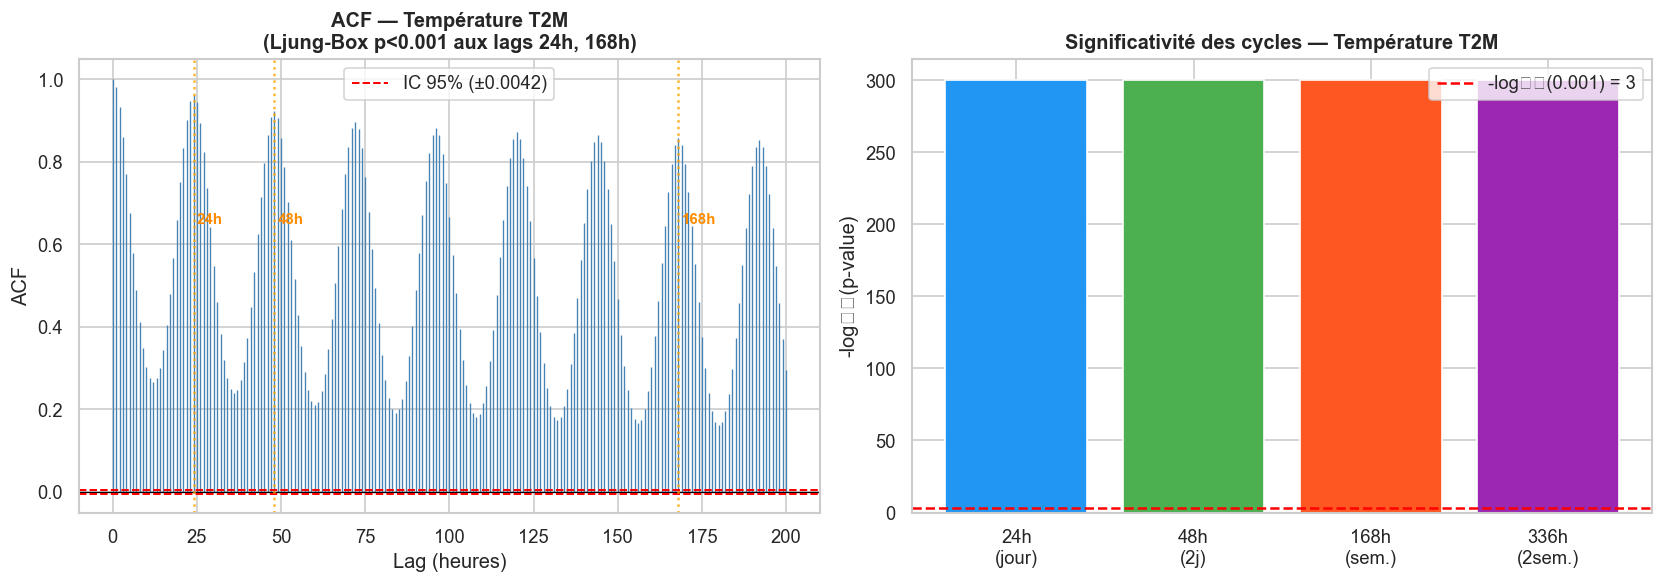


Test de Ljung-Box — Irradiation ALLSKY
  (H0 = pas d'autocorrélation jusqu'au lag k)
                   Lag |       Q-stat |      p-value | Décision
  ------------------------------------------------------------
      24h (journalier) |    1605595.0 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF
         48h (2 jours) |    3177723.9 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF
   168h (hebdomadaire) |   10954897.3 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF
     336h (2 semaines) |   21793406.2 |     0.00e+00 | Rejet H0 *** CYCLE SIGNIFICATIF

→ Les cycles à 24h et 168h sont statistiquement prouvés (p ≪ 0.001)


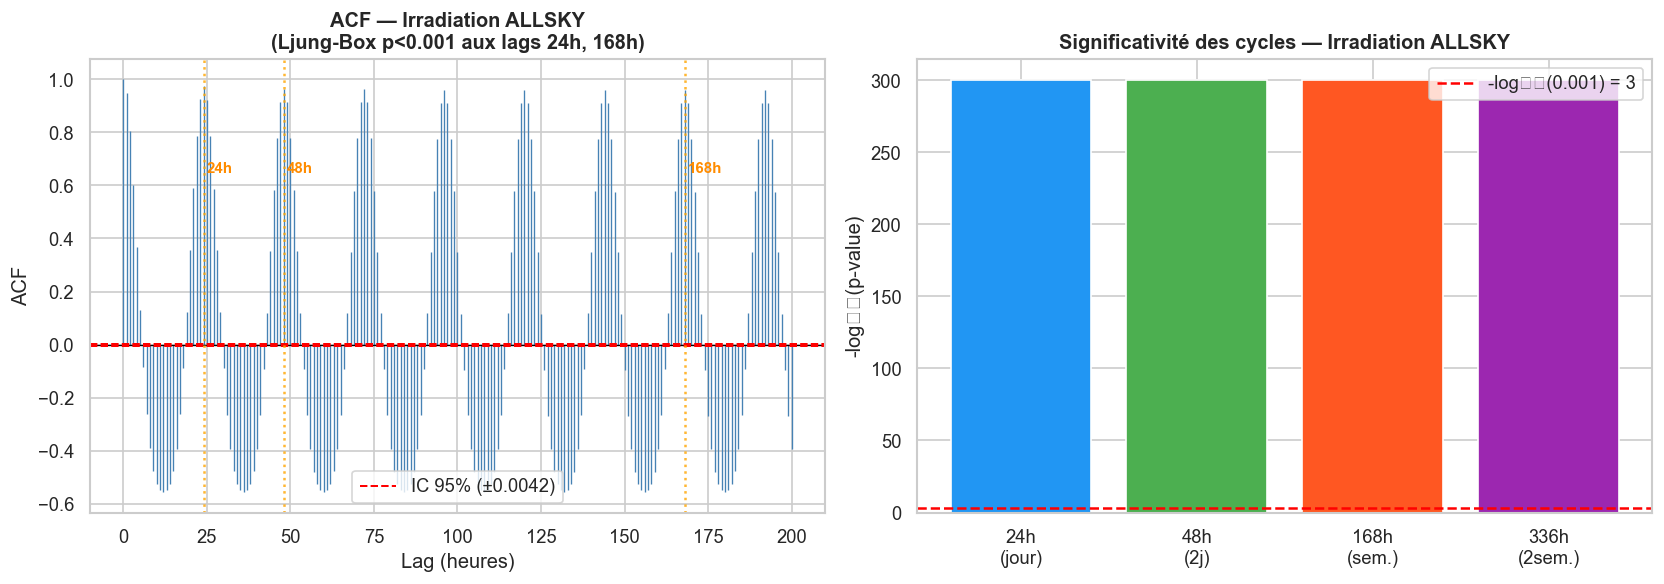

In [6]:
def ljungbox_analysis(series, name, unit):
    """Test de Ljung-Box + visualisation ACF."""
    series_clean = series.dropna()
    lb_res = acorr_ljungbox(series_clean, lags=[24, 48, 168, 336], return_df=True)
    
    print("="*65)
    print(f"Test de Ljung-Box — {name}")
    print("  (H0 = pas d'autocorrélation jusqu'au lag k)")
    print("="*65)
    print(f"  {'Lag':>20} | {'Q-stat':>12} | {'p-value':>12} | Décision")
    print("  " + "-"*60)
    lag_labels = {24: "24h (journalier)", 48: "48h (2 jours)", 
                  168: "168h (hebdomadaire)", 336: "336h (2 semaines)"}
    for lag, row in lb_res.iterrows():
        decision = "Rejet H0 *** CYCLE SIGNIFICATIF" if row["lb_pvalue"] < 0.001 else "Non significatif"
        print(f"  {lag_labels[lag]:>20} | {row['lb_stat']:12.1f} | {row['lb_pvalue']:12.2e} | {decision}")
    
    print()
    print(f"→ Les cycles à 24h et 168h sont statistiquement prouvés (p ≪ 0.001)")
    
    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    acf_vals = acf(series_clean, nlags=200, fft=True)
    lags = np.arange(len(acf_vals))
    conf = 1.96 / np.sqrt(len(series_clean))
    axes[0].vlines(lags, 0, acf_vals, color="steelblue", lw=0.8)
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].axhline(conf, color="red", lw=1.2, ls="--", label=f"IC 95% (±{conf:.4f})")
    axes[0].axhline(-conf, color="red", lw=1.2, ls="--")
    for lag_h, label in [(24,"24h"),(48,"48h"),(168,"168h")]:
        axes[0].axvline(lag_h, color="orange", lw=1.5, ls=":", alpha=0.8)
        axes[0].text(lag_h+1, 0.65, label, color="darkorange", fontsize=9, fontweight="bold")
    axes[0].set_title(f"ACF — {name}\n(Ljung-Box p<0.001 aux lags 24h, 168h)", fontweight="bold")
    axes[0].set_xlabel("Lag (heures)"); axes[0].set_ylabel("ACF"); axes[0].legend()
    
    # p-values
    axes[1].bar(["24h\n(jour)","48h\n(2j)","168h\n(sem.)","336h\n(2sem.)"],
                -np.log10([lb_res.loc[l,"lb_pvalue"]+1e-300 for l in [24,48,168,336]]),
                color=["#2196F3","#4CAF50","#FF5722","#9C27B0"])
    axes[1].axhline(3, color="red", ls="--", lw=1.5, label="-log₁₀(0.001) = 3")
    axes[1].set_ylabel("-log₁₀(p-value)")
    axes[1].set_title(f"Significativité des cycles — {name}", fontweight="bold")
    axes[1].legend()
    plt.tight_layout(); plt.show()
    print()

ljungbox_analysis(df["T2M"], "Température T2M", "°C")
ljungbox_analysis(df["ALLSKY"], "Irradiation ALLSKY", "W/m²")


## 5. Analyse spectrale — Identification des fréquences dominantes

Le périodogramme permet de **quantifier** l'énergie spectrale associée à chaque fréquence.
Les pics identifiés correspondent à des cycles réels dans la série.


Top 8 fréquences dominantes — Température T2M
     Fréquence |  Période (h) |      Puissance | Interprétation
  ----------------------------------------------------------------------
      0.000114 |       8765.8 |       7.32e+06 | Harmonique
      0.041667 |         24.0 |       5.30e+06 | Cycle journalier ★
      0.083333 |         12.0 |       3.75e+05 | Harmonique 2×/jour ★
      0.000228 |       4382.9 |       1.24e+05 | Harmonique
      0.041553 |         24.1 |       1.23e+05 | Harmonique
      0.041781 |         23.9 |       6.36e+04 | Harmonique
      0.000005 |     219144.0 |       3.24e+04 | Harmonique
      0.000073 |      13696.5 |       2.89e+04 | Harmonique


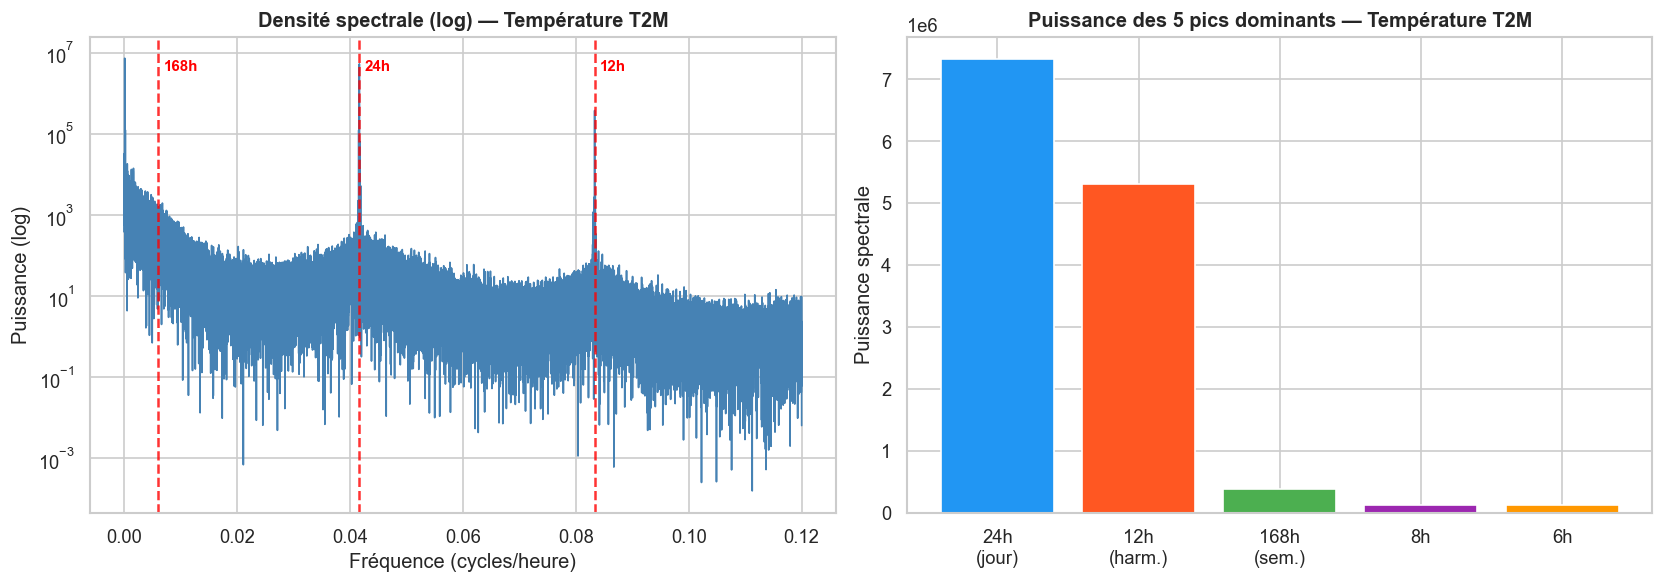


Top 8 fréquences dominantes — Irradiation ALLSKY
     Fréquence |  Période (h) |      Puissance | Interprétation
  ----------------------------------------------------------------------
      0.041666 |         24.0 |       1.22e+10 | Cycle journalier ★
      0.041670 |         24.0 |       1.33e+09 | Cycle journalier ★
      0.083331 |         12.0 |       1.25e+09 | Harmonique 2×/jour ★
      0.083336 |         12.0 |       1.25e+09 | Harmonique 2×/jour ★
      0.000114 |       8737.2 |       1.08e+09 | Harmonique
      0.041780 |         23.9 |       5.76e+08 | Harmonique
      0.041661 |         24.0 |       4.88e+08 | Cycle journalier ★
      0.041551 |         24.1 |       2.76e+08 | Harmonique


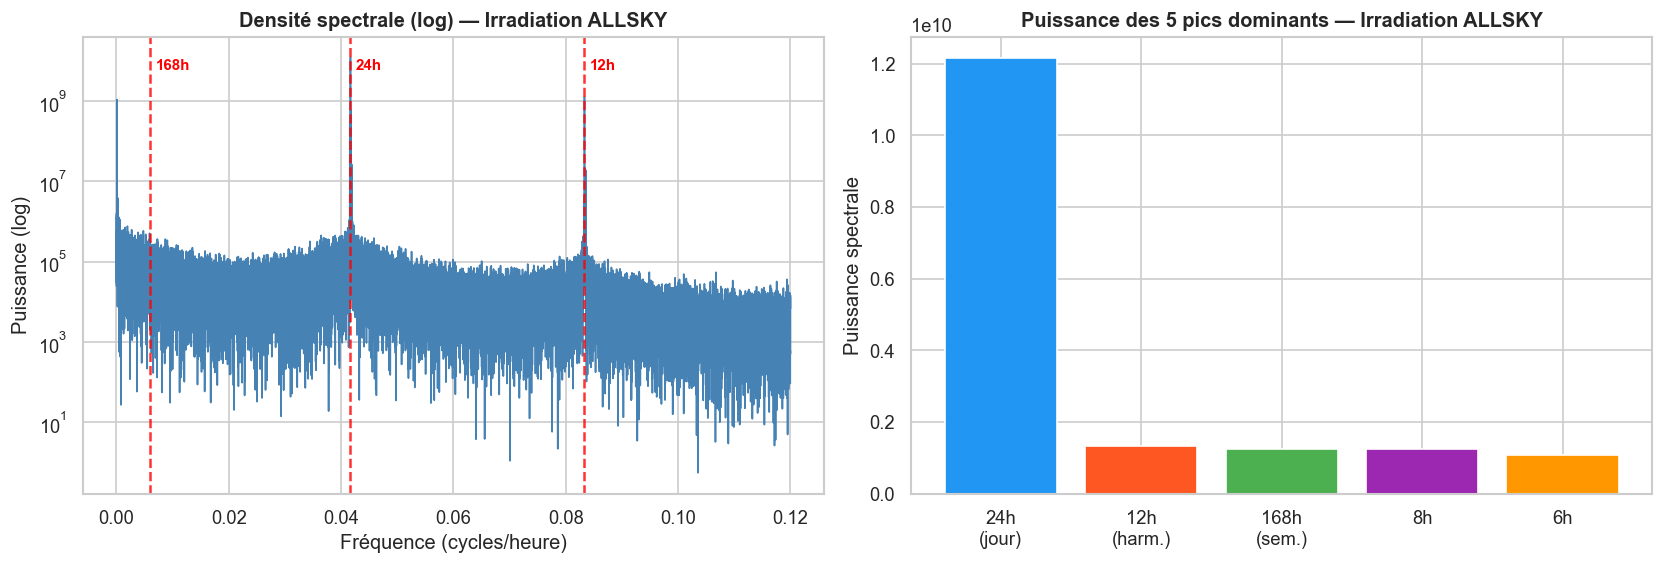

In [7]:
def spectral_analysis(series, name, unit):
    """Analyse spectrale par périodogramme."""
    series_clean = series.dropna()
    freq, power = periodogram(series_clean, fs=1.0)
    
    with np.errstate(divide="ignore"):
        period = np.where(freq[1:] > 0, 1.0 / freq[1:], np.inf)
    p_arr = power[1:]
    top_idx = np.argsort(p_arr)[-8:][::-1]
    
    print("="*60)
    print(f"Top 8 fréquences dominantes — {name}")
    print("="*60)
    print(f"  {'Fréquence':>12} | {'Période (h)':>12} | {'Puissance':>14} | Interprétation")
    print("  " + "-"*70)
    interp_map = {24.0: "Cycle journalier ★", 12.0: "Harmonique 2×/jour ★",
                  168.0: "Cycle hebdomadaire ★", 8760.0: "Cycle annuel ★",
                  8.0: "Harmonique 3×/jour", 6.0: "Harmonique 4×/jour"}
    for i in top_idx:
        p_h = round(period[i], 1)
        label = interp_map.get(p_h, "Harmonique")
        print(f"  {freq[i+1]:12.6f} | {period[i]:12.1f} | {p_arr[i]:14.2e} | {label}")
    
    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    mask = (freq > 0) & (freq < 0.12)
    axes[0].semilogy(freq[mask], power[mask], color="steelblue", lw=1)
    for f_peak, label in [(1/24,"24h"),(1/12,"12h"),(1/168,"168h")]:
        axes[0].axvline(f_peak, color="red", lw=1.5, ls="--", alpha=0.8)
        axes[0].text(f_peak + 0.001, power[mask].max()*0.5, label, color="red", fontsize=9, fontweight="bold")
    axes[0].set_title(f"Densité spectrale (log) — {name}", fontweight="bold")
    axes[0].set_xlabel("Fréquence (cycles/heure)"); axes[0].set_ylabel("Puissance (log)")
    
    peak_labels = ["24h\n(jour)","12h\n(harm.)","168h\n(sem.)","8h","6h"]
    peak_powers = sorted([p_arr[i] for i in top_idx[:5]], reverse=True)
    axes[1].bar(range(len(peak_powers)), peak_powers, color=COLORS[:len(peak_powers)])
    axes[1].set_xticks(range(len(peak_powers)))
    axes[1].set_xticklabels(peak_labels[:len(peak_powers)])
    axes[1].set_title(f"Puissance des 5 pics dominants — {name}", fontweight="bold")
    axes[1].set_ylabel("Puissance spectrale")
    plt.tight_layout(); plt.show()
    print()

spectral_analysis(df["T2M"], "Température T2M", "°C")
spectral_analysis(df["ALLSKY"], "Irradiation ALLSKY", "W/m²")


## 6. Régimes thermiques et d'irradiation — Validation statistique

Nous testons formellement si les régimes définis par percentiles sont **statistiquement distincts** 
avec un test de Kruskal-Wallis (non-paramétrique) suivi de tests post-hoc Mann-Whitney 
avec correction de Bonferroni.



Répartition des régimes :
T2M
Moyen        72314
Haut         52556
Bas          50469
Très bas     21921
Très haut    21884
Name: count, dtype: int64
Test de Kruskal-Wallis — 5 régimes de Température T2M
  H = 205131.71, p-value = 0.00e+00
  → Régimes STATISTIQUEMENT DISTINCTS ✓ (p < 0.001)

           count   mean   std    min    max
regime                                     
Très bas   21921   7.48  1.70  -3.35   9.54
Bas        50469  12.37  1.62   9.55  15.19
Moyen      72314  18.87  2.09  15.20  22.67
Haut       52556  26.78  2.70  22.68  32.13
Très haut  21884  36.50  3.42  32.14  47.51

Tests post-hoc Mann-Whitney U (Bonferroni) :
  α_bonf = 0.0050
  Régime 1         vs Régime 2         | p-value      | Significatif
  ------------------------------------------------------------
  Très bas         vs Bas              | 0.00e+00     | *** ✓
  Très bas         vs Moyen            | 0.00e+00     | *** ✓
  Très bas         vs Haut             | 0.00e+00     | *** ✓
  Très bas     

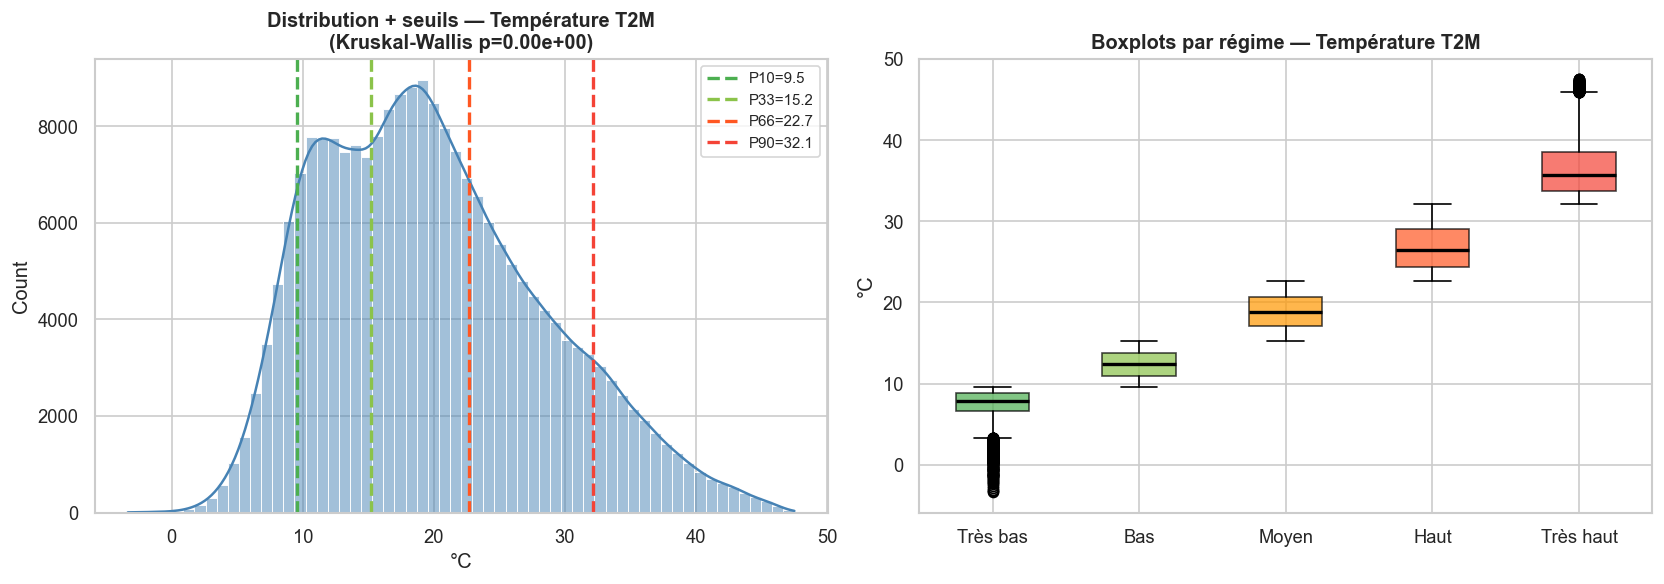



Répartition des régimes :
ALLSKY
Très bas     103659
Haut          52427
Moyen         40506
Très haut     21838
Name: count, dtype: int64
Test de Kruskal-Wallis — 5 régimes de Irradiation ALLSKY
  H = 213243.34, p-value = 0.00e+00
  → Régimes STATISTIQUEMENT DISTINCTS ✓ (p < 0.001)

              count    mean     std     min      max
regime                                              
Très bas   103659.0    0.00    0.00    0.00     0.00
Bas             NaN     NaN     NaN     NaN      NaN
Moyen       40506.0  110.96   87.29    1.17   283.05
Haut        52427.0  517.18  136.98  283.08   759.67
Très haut   21838.0  892.67   76.06  759.70  1065.62

Tests post-hoc Mann-Whitney U (Bonferroni) :
  α_bonf = 0.0083
  Régime 1         vs Régime 2         | p-value      | Significatif
  ------------------------------------------------------------
  Très bas         vs Moyen            | 0.00e+00     | *** ✓
  Très bas         vs Haut             | 0.00e+00     | *** ✓
  Très bas         vs 

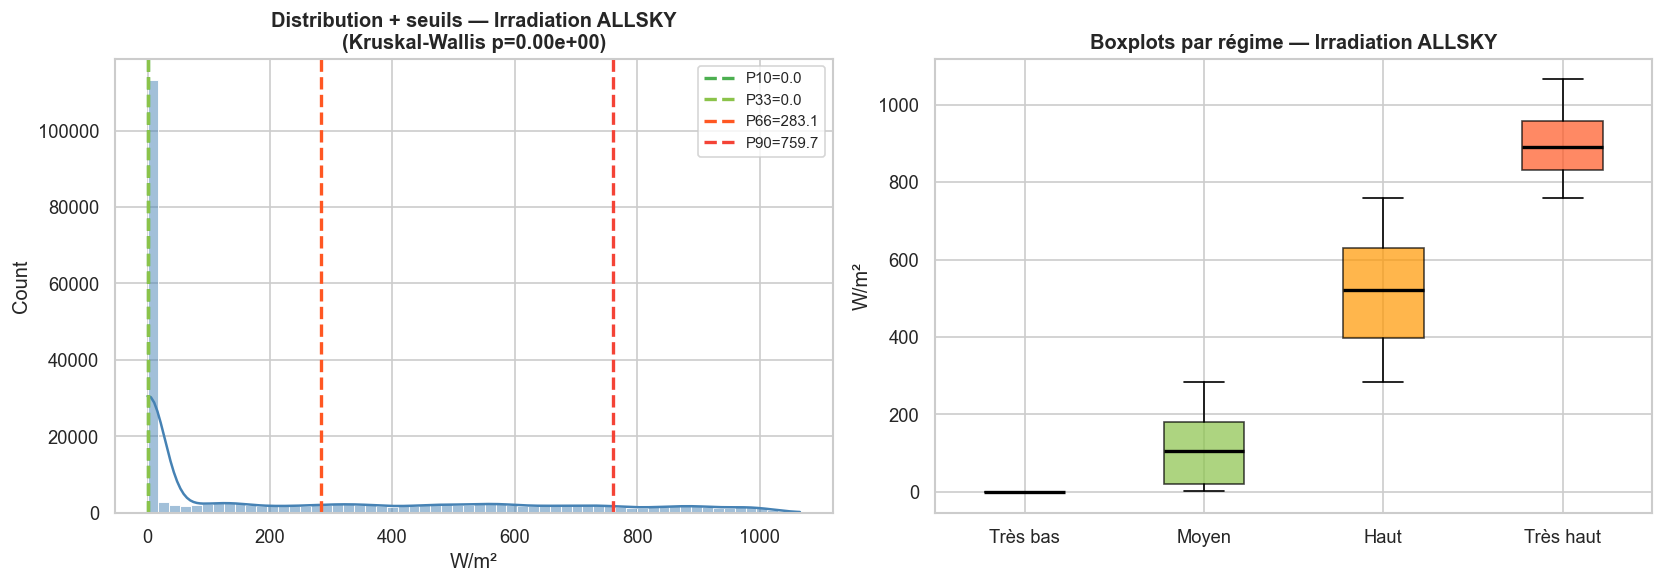

In [12]:
def regime_analysis(series, name, unit):
    """Analyse des régimes par percentiles + tests statistiques (robuste)."""
    
    

    series_clean = series.dropna()
    
    # Percentiles
    p10 = np.percentile(series_clean, 10)
    p33 = np.percentile(series_clean, 33)
    p66 = np.percentile(series_clean, 66)
    p90 = np.percentile(series_clean, 90)
    
    # Attribution des régimes
    def assign_regime(v):
        if v <= p10:   return "Très bas"
        elif v <= p33: return "Bas"
        elif v <= p66: return "Moyen"
        elif v <= p90: return "Haut"
        else:          return "Très haut"
    
    regimes = series_clean.apply(assign_regime)
    regime_order = ["Très bas","Bas","Moyen","Haut","Très haut"]
    
    # DEBUG (important pour ALLSKY)
    print("\nRépartition des régimes :")
    print(regimes.value_counts())
    
    # Groupes
    groups = [series_clean[regimes == r].values for r in regime_order]
    groups_non_empty = [g for g in groups if len(g) > 0]
    
    # ========================
    # TEST KRUSKAL-WALLIS
    # ========================
    print("="*65)
    print(f"Test de Kruskal-Wallis — 5 régimes de {name}")
    print("="*65)
    
    if len(groups_non_empty) >= 2:
        kw_stat, kw_p = stats.kruskal(*groups_non_empty)
        print(f"  H = {kw_stat:.2f}, p-value = {kw_p:.2e}")
        print(f"  → {'Régimes STATISTIQUEMENT DISTINCTS ✓ (p < 0.001)' if kw_p < 0.001 else 'Non significatif'}")
    else:
        kw_stat, kw_p = np.nan, np.nan
        print("  ⚠️ Pas assez de groupes pour effectuer le test")
    
    print()
    
    # ========================
    # STATISTIQUES DESCRIPTIVES
    # ========================
    regime_df = pd.DataFrame({"value": series_clean, "regime": regimes})
    
    stats_df = regime_df.groupby("regime")["value"].agg(
        ["count","mean","std","min","max"]
    ).round(2)
    
    # 🔥 FIX PRINCIPAL (évite KeyError)
    stats_df = stats_df.reindex(regime_order)
    
    print(stats_df)
    
    # ========================
    # TEST POST-HOC
    # ========================
    print("\nTests post-hoc Mann-Whitney U (Bonferroni) :")
    
    valid_regimes = [r for r in regime_order if np.sum(regimes == r) > 0]
    
    n_comp = len(valid_regimes) * (len(valid_regimes) - 1) // 2
    alpha_bonf = 0.05 / n_comp if n_comp > 0 else np.nan
    
    print(f"  α_bonf = {alpha_bonf:.4f}")
    print(f"  {'Régime 1':16} vs {'Régime 2':16} | p-value      | Significatif")
    print("  " + "-"*60)
    
    for i, r1 in enumerate(valid_regimes):
        for r2 in valid_regimes[i+1:]:
            g1 = series_clean[regimes == r1]
            g2 = series_clean[regimes == r2]
            
            if len(g1) > 0 and len(g2) > 0:
                u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
                sig = "*** ✓" if p < alpha_bonf else "    ✗"
                print(f"  {r1:16} vs {r2:16} | {p:.2e}     | {sig}")
    
    # ========================
    # VISUALISATION
    # ========================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_regime = ["#4CAF50","#8BC34A","#FF9800","#FF5722","#F44336"]
    
    # Histogramme
    sns.histplot(series_clean, bins=60, kde=True,
                 ax=axes[0], color="steelblue", alpha=0.5)
    
    for thresh, label, color in [
        (p10, f"P10={p10:.1f}", colors_regime[0]),
        (p33, f"P33={p33:.1f}", colors_regime[1]),
        (p66, f"P66={p66:.1f}", colors_regime[3]),
        (p90, f"P90={p90:.1f}", colors_regime[4])
    ]:
        axes[0].axvline(thresh, color=color, lw=2, ls="--", label=label)
    
    axes[0].legend(fontsize=9)
    axes[0].set_title(
        f"Distribution + seuils — {name}\n(Kruskal-Wallis p={kw_p:.2e})",
        fontweight="bold"
    )
    axes[0].set_xlabel(unit)
    
    # Boxplot (uniquement groupes existants)
    valid_groups = [series_clean[regimes == r] for r in regime_order if np.sum(regimes == r) > 0]
    valid_labels = [r for r in regime_order if np.sum(regimes == r) > 0]
    
    bp = axes[1].boxplot(valid_groups, labels=valid_labels,
                         patch_artist=True,
                         medianprops=dict(color="black", lw=2))
    
    for patch, color in zip(bp["boxes"], colors_regime[:len(valid_groups)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_ylabel(unit)
    axes[1].set_title(f"Boxplots par régime — {name}", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    print()

regime_analysis(df["T2M"], "Température T2M", "°C")
regime_analysis(df["ALLSKY"], "Irradiation ALLSKY", "W/m²")


## 7. Saisonnalité mensuelle — Test statistique

Le test de Kruskal-Wallis entre les 12 mois valide statistiquement la présence
d'une saisonnalité annuelle.


Kruskal-Wallis mensuel — Température T2M : H = 103576.47, p = 0.00e+00
→ Saisonnalité annuelle significative : OUI ✓


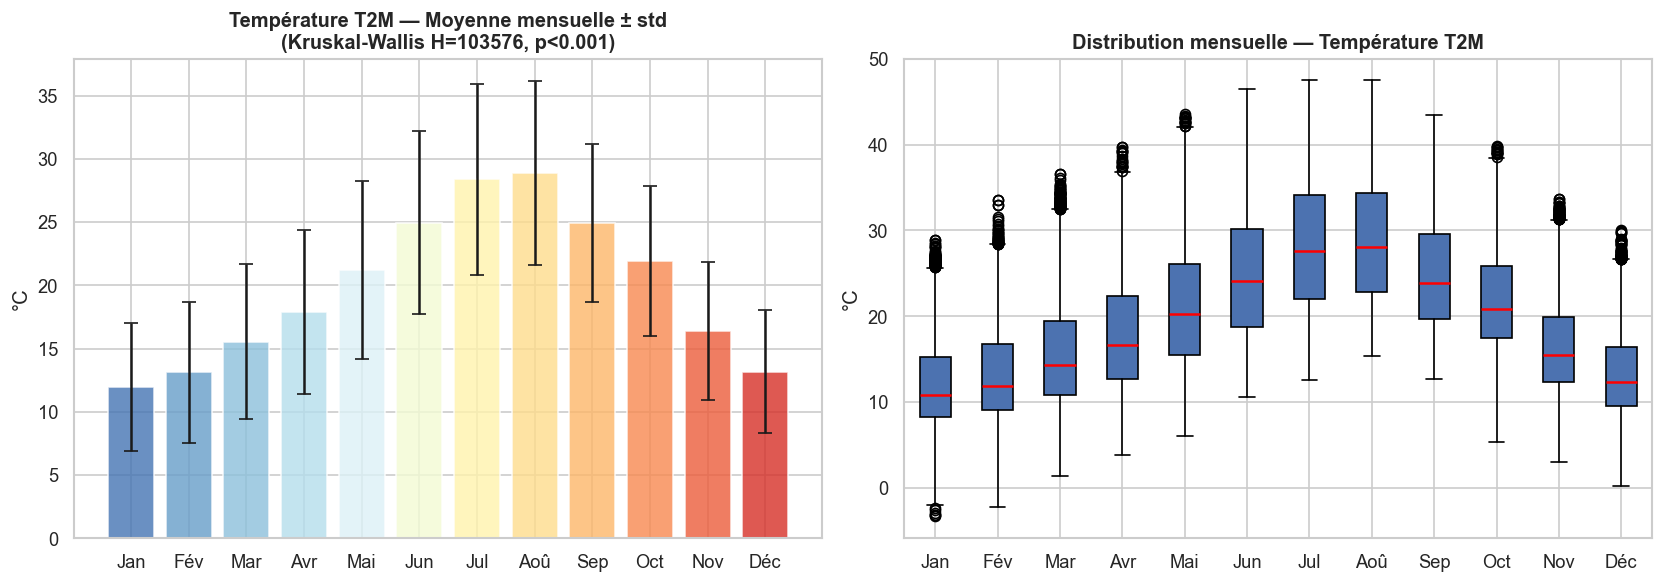


Kruskal-Wallis mensuel — Irradiation ALLSKY : H = 7326.28, p = 0.00e+00
→ Saisonnalité annuelle significative : OUI ✓


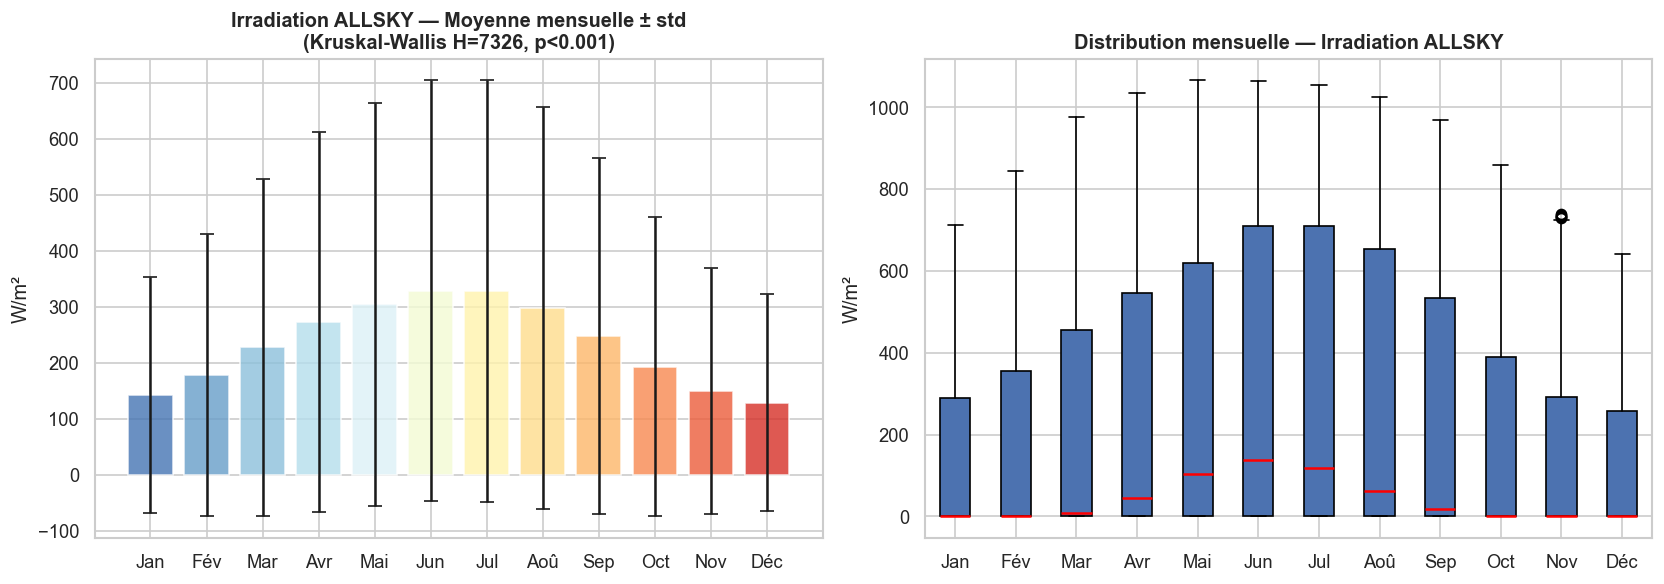

In [13]:
def monthly_seasonality(series, name, unit):
    """Test de saisonnalité mensuelle + visualisation."""
    series_clean = series.dropna()
    months = series_clean.index.month
    monthly_groups = [series_clean[months==m].values for m in range(1,13)]
    kw_stat, kw_p = stats.kruskal(*monthly_groups)
    
    print(f"Kruskal-Wallis mensuel — {name} : H = {kw_stat:.2f}, p = {kw_p:.2e}")
    print(f"→ Saisonnalité annuelle significative : {'OUI ✓' if kw_p < 0.001 else 'NON'}")
    
    month_labels = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    monthly_means = [np.mean(g) for g in monthly_groups]
    monthly_stds  = [np.std(g) for g in monthly_groups]
    axes[0].bar(month_labels, monthly_means, yerr=monthly_stds, capsize=4,
                color=plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 12)), alpha=0.8)
    axes[0].set_ylabel(f"{unit}")
    axes[0].set_title(f"{name} — Moyenne mensuelle ± std\n(Kruskal-Wallis H={kw_stat:.0f}, p<0.001)", fontweight="bold")
    
    axes[1].boxplot(monthly_groups, labels=month_labels, patch_artist=True,
                    medianprops=dict(color="red", lw=1.5))
    axes[1].set_ylabel(f"{unit}")
    axes[1].set_title(f"Distribution mensuelle — {name}", fontweight="bold")
    plt.tight_layout(); plt.show()
    print()

monthly_seasonality(df["T2M"], "Température T2M", "°C")
monthly_seasonality(df["ALLSKY"], "Irradiation ALLSKY", "W/m²")


## 8. Décomposition STL

La décomposition STL (Seasonal and Trend decomposition using Loess) sépare la série en :
- **Tendance T(t)** : évolution long-terme
- **Saisonnalité S(t)** : composante cyclique
- **Résidus R(t)** : bruit restant


Décomposition STL — Température T2M (période=24h) :
  Tendance    : 60.0%
  Saisonnalité: 38.2%
  Résidus     : 0.8%


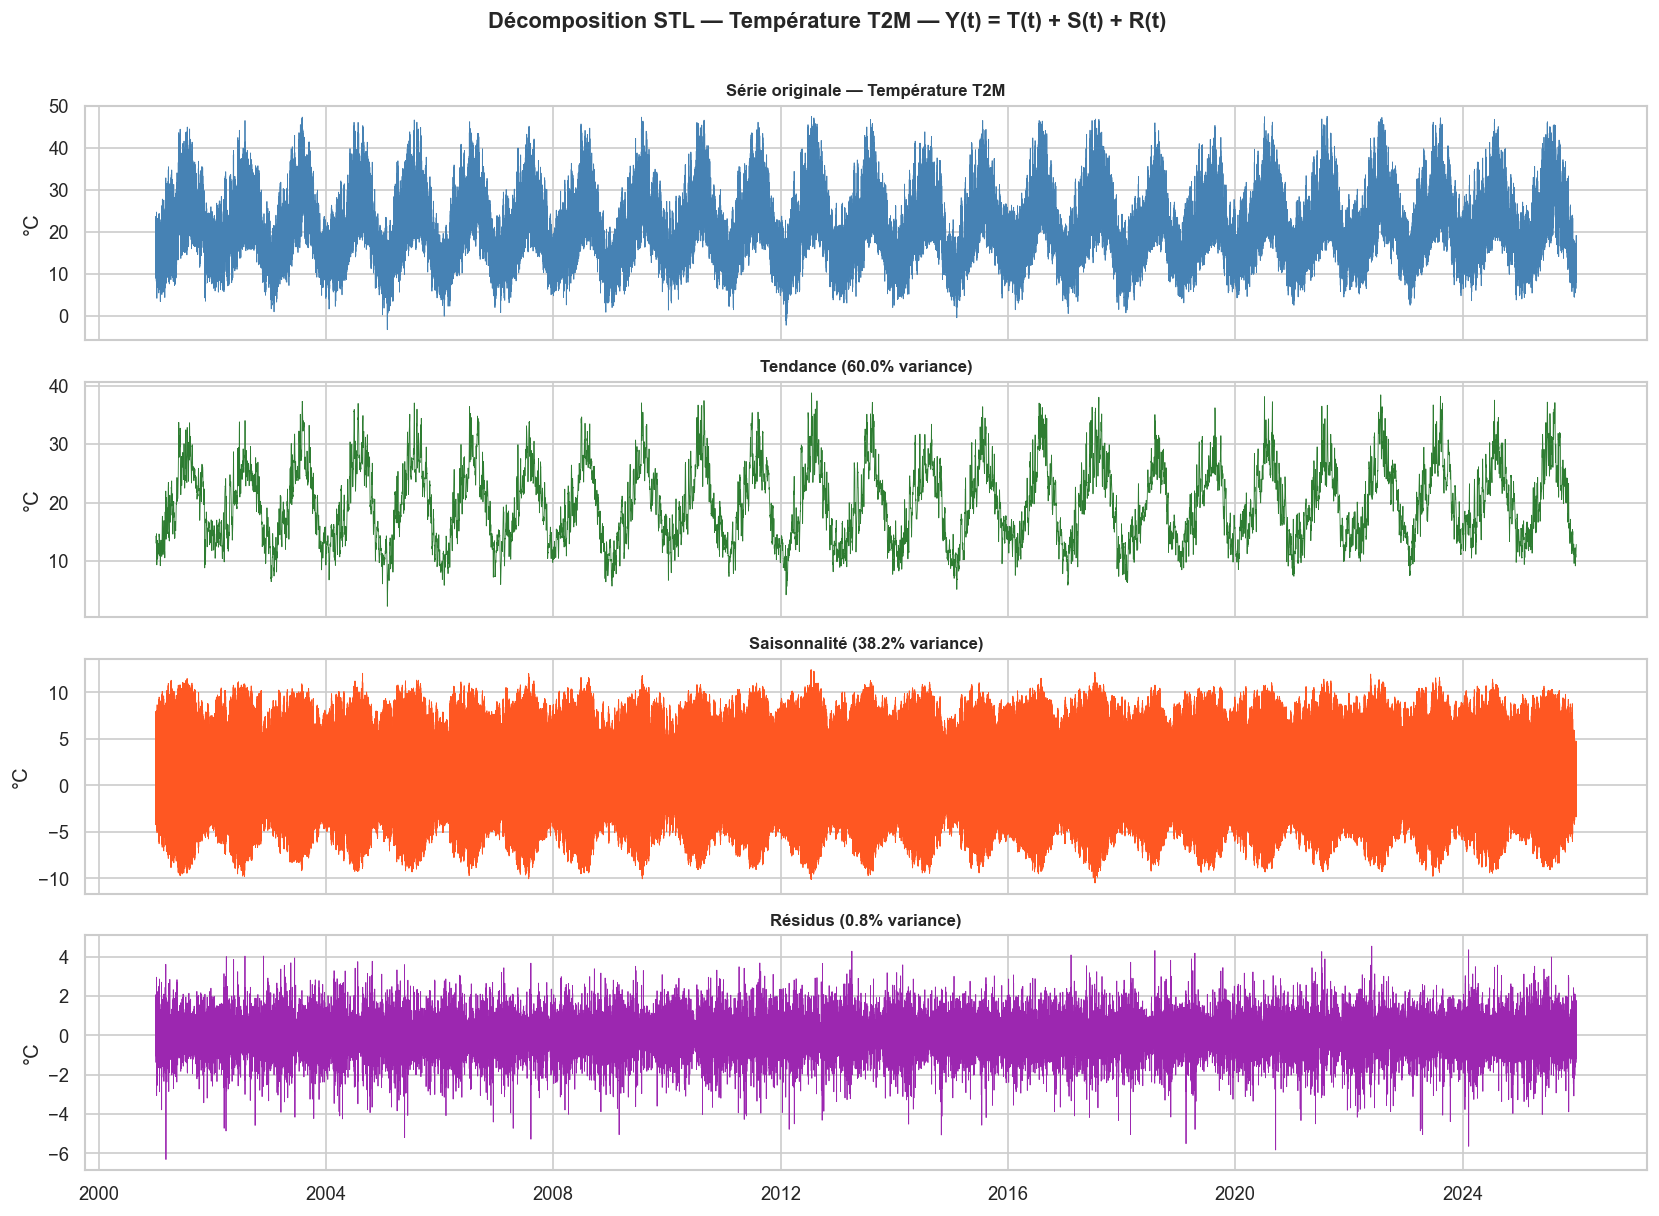


Décomposition STL — Irradiation ALLSKY (période=24h) :
  Tendance    : 6.4%
  Saisonnalité: 91.8%
  Résidus     : 1.1%


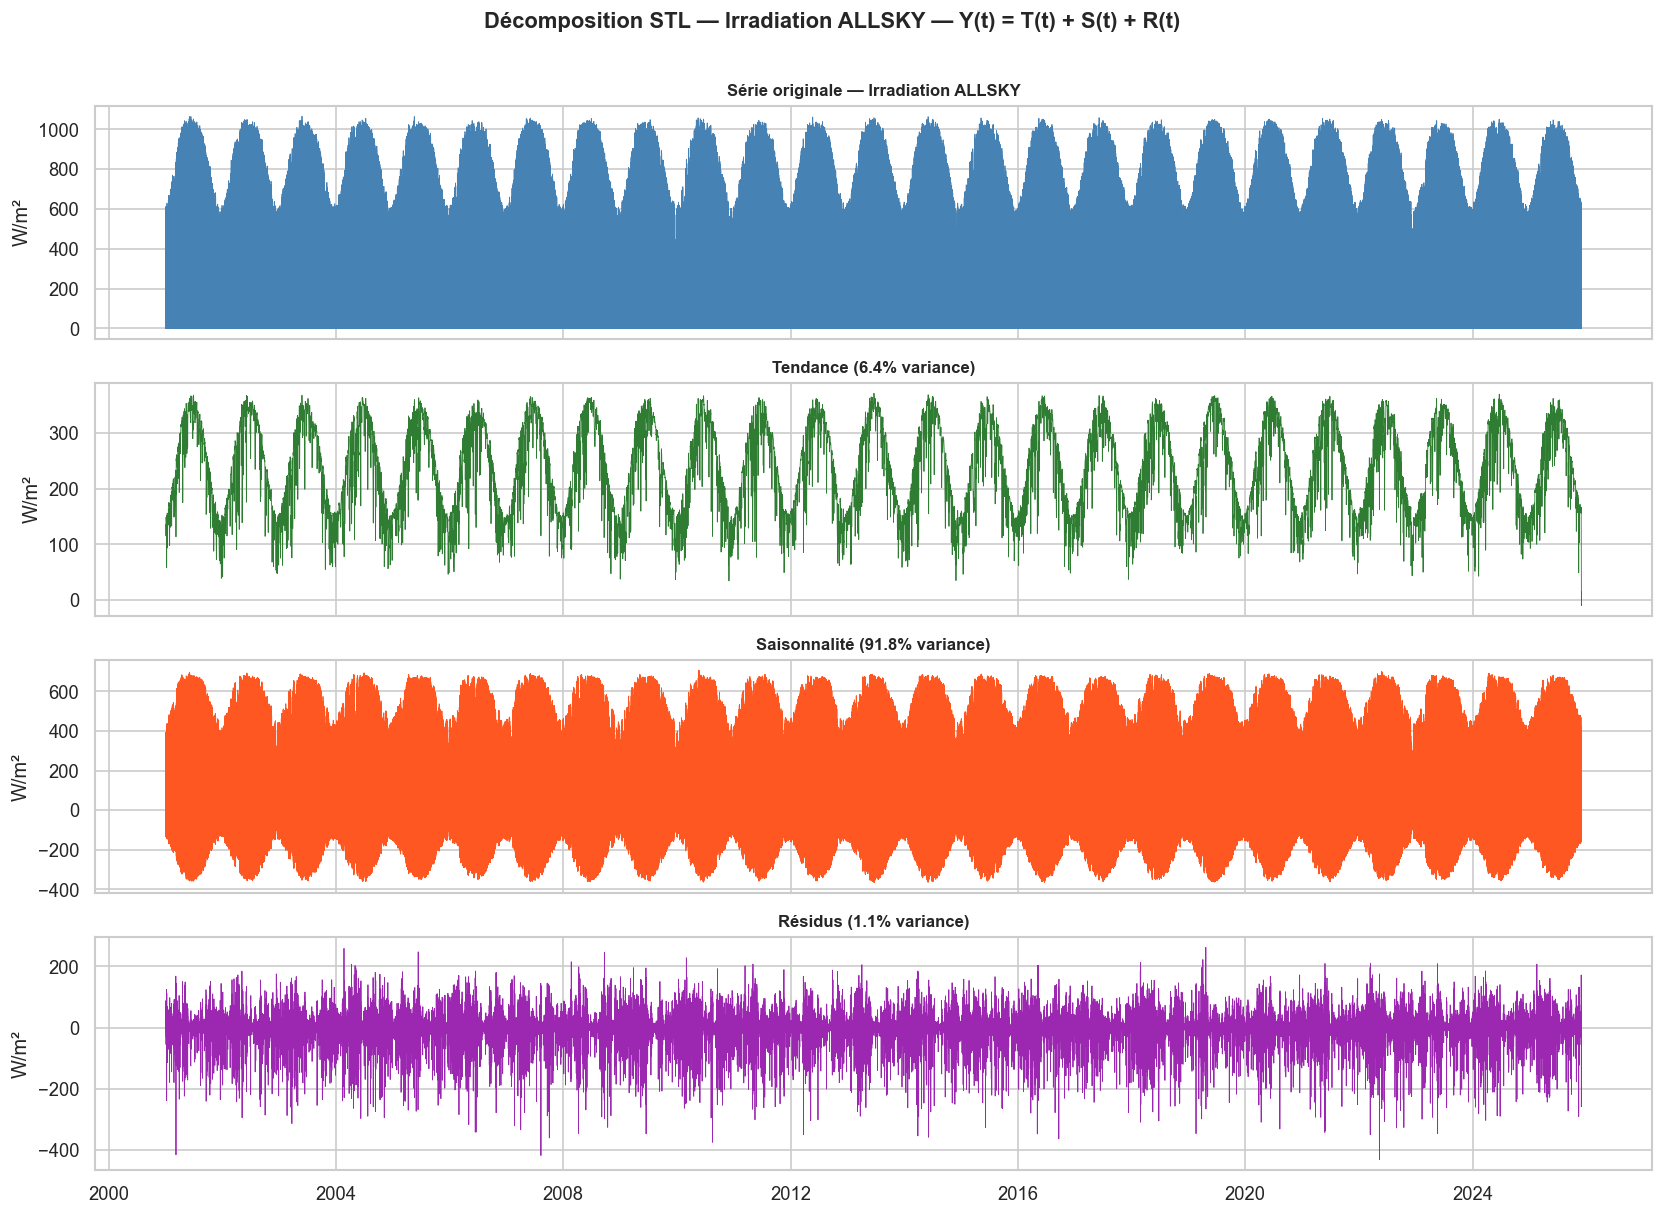

In [14]:
def stl_decomposition(series, name, unit, period=24):
    """Décomposition STL + quantification des composantes."""
    series_clean = series.dropna()
    stl = STL(series_clean, period=period)
    result = stl.fit()
    
    var_trend    = np.var(result.trend)
    var_seasonal = np.var(result.seasonal)
    var_resid    = np.var(result.resid)
    var_total    = np.var(series_clean)
    
    print(f"Décomposition STL — {name} (période={period}h) :")
    print(f"  Tendance    : {var_trend/var_total*100:.1f}%")
    print(f"  Saisonnalité: {var_seasonal/var_total*100:.1f}%")
    print(f"  Résidus     : {var_resid/var_total*100:.1f}%")
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    for ax, (title, data, color) in zip(axes, [
        (f"Série originale — {name}", series_clean, "steelblue"),
        (f"Tendance ({var_trend/var_total*100:.1f}% variance)", result.trend, "#2e7d32"),
        (f"Saisonnalité ({var_seasonal/var_total*100:.1f}% variance)", result.seasonal, "#FF5722"),
        (f"Résidus ({var_resid/var_total*100:.1f}% variance)", result.resid, "#9C27B0")]):
        ax.plot(data, color=color, lw=0.5)
        ax.set_title(title, fontweight="bold", fontsize=10)
        ax.set_ylabel(f"{unit}")
    plt.suptitle(f"Décomposition STL — {name} — Y(t) = T(t) + S(t) + R(t)", fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()
    print()

stl_decomposition(df["T2M"], "Température T2M", "°C", period=24)
stl_decomposition(df["ALLSKY"], "Irradiation ALLSKY", "W/m²", period=24)


## 9. PCA des profils journaliers

La PCA réduit la dimensionnalité des profils journaliers (24 dimensions) pour
identifier les axes de variation principaux, avant clustering.

Nous analysons **séparément** la température et l'irradiation, puis réalisons une **PCA combinée** pour le clustering.


Nb de jours complets (T2M + ALLSKY) : 9101

Variance cumulée :
  PC1: 76.1%
  PC2: 91.0%
  PC3: 95.1%
  PC4: 96.3%
  PC5: 97.4%
  → 2 composantes capturent ≥ 90% de la variance
  → Réduction : 48 dimensions → 2 dimensions


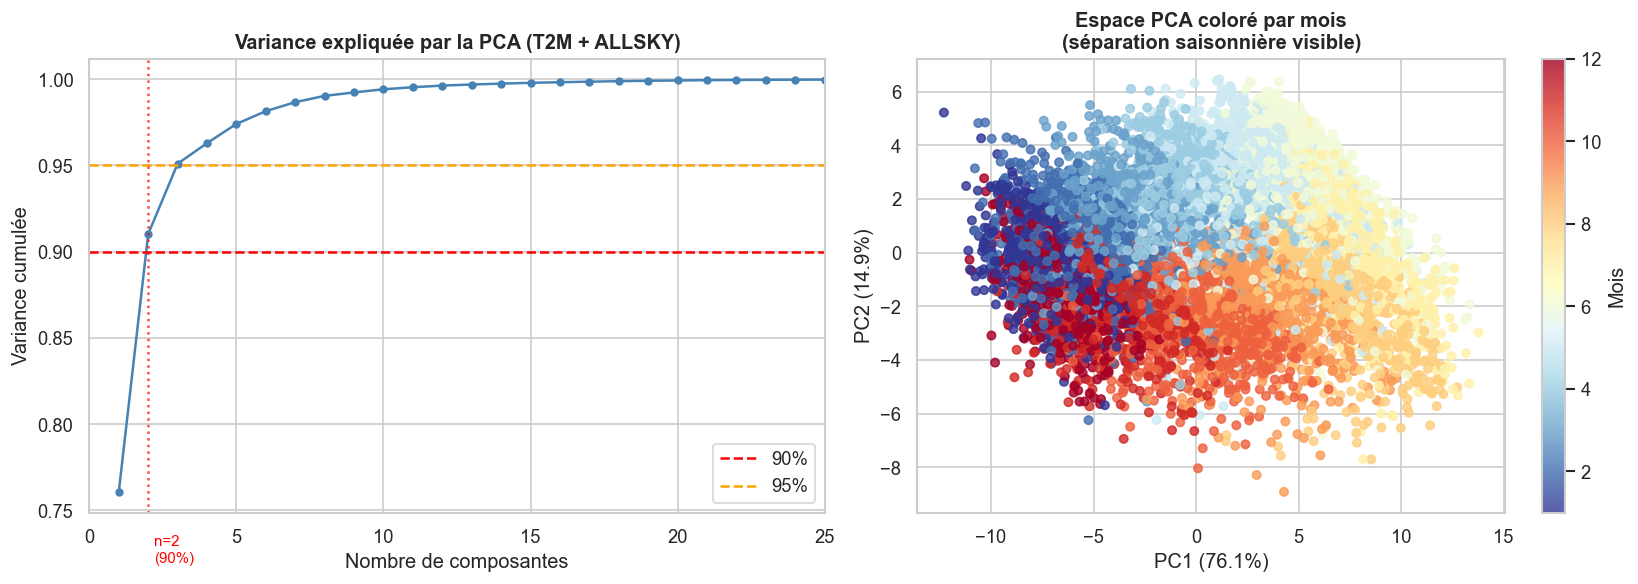

In [15]:
# ── Profils journaliers de TEMPÉRATURE ────────────────────────────
daily_t2m = df["T2M"].groupby([df.index.date, df.index.hour]).mean().unstack()
daily_t2m.index = pd.to_datetime(daily_t2m.index)
daily_t2m.columns = [f"T_h{h}" for h in range(24)]
daily_t2m = daily_t2m.dropna()

# ── Profils journaliers d'IRRADIATION ────────────────────────────
daily_allsky = df["ALLSKY"].groupby([df.index.date, df.index.hour]).mean().unstack()
daily_allsky.index = pd.to_datetime(daily_allsky.index)
daily_allsky.columns = [f"S_h{h}" for h in range(24)]
daily_allsky = daily_allsky.dropna()

# ── Fusion : jours présents dans les deux variables ──────────────
common_days = daily_t2m.index.intersection(daily_allsky.index)
daily_t2m   = daily_t2m.loc[common_days]
daily_allsky = daily_allsky.loc[common_days]
daily_combined = pd.concat([daily_t2m, daily_allsky], axis=1)
print(f"Nb de jours complets (T2M + ALLSKY) : {len(daily_combined)}")

# ── PCA sur les profils combinés (48 dimensions → réduction) ────
scaler = StandardScaler()
X = scaler.fit_transform(daily_combined)
pca = PCA()
X_pca = pca.fit_transform(X)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n90 = int(np.argmax(cumvar >= 0.90) + 1)
n95 = int(np.argmax(cumvar >= 0.95) + 1)
X_red = X_pca[:, :n90]

print(f"\nVariance cumulée :")
for n in [1,2,3,4,5]:
    print(f"  PC{n}: {cumvar[n-1]*100:.1f}%")
print(f"  → {n90} composantes capturent ≥ 90% de la variance")
print(f"  → Réduction : 48 dimensions → {n90} dimensions")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumvar)+1), cumvar, marker="o", ms=4, color="steelblue")
axes[0].axhline(0.90, color="red", ls="--", lw=1.5, label="90%")
axes[0].axhline(0.95, color="orange", ls="--", lw=1.5, label="95%")
axes[0].axvline(n90, color="red", ls=":", alpha=0.7)
axes[0].text(n90+0.2, 0.72, f"n={n90}\n(90%)", color="red", fontsize=9)
axes[0].set_xlim(0, min(25, len(cumvar)))
axes[0].set_xlabel("Nombre de composantes")
axes[0].set_ylabel("Variance cumulée")
axes[0].set_title("Variance expliquée par la PCA (T2M + ALLSKY)", fontweight="bold")
axes[0].legend()

sc = axes[1].scatter(X_pca[:,0], X_pca[:,1],
                     c=daily_combined.index.month, cmap="RdYlBu_r", alpha=0.8, s=25)
plt.colorbar(sc, ax=axes[1], label="Mois")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Espace PCA coloré par mois\n(séparation saisonnière visible)", fontweight="bold")
plt.tight_layout(); plt.show()


## 10. Clustering — Validation multi-critères

Pour choisir le nombre optimal de clusters **k**, trois indicateurs complémentaires sont calculés :

- **Silhouette** (↑) : cohésion intra-cluster et séparation inter-cluster — `max = k optimal`
- **Davies-Bouldin** (↓) : rapport distance intra/inter — `min = k optimal`
- **Calinski-Harabasz** (↑) : dispersion inter vs intra — `max = k optimal`

Le k retenu est celui obtenu par **vote majoritaire** des trois critères.


Indicateurs de validation :
    silhouette  davies_bouldin  calinski_harabasz      inertia
k                                                             
2       0.5243          0.6877         15567.9591  119174.5168
3       0.4095          0.9451         12649.4259   85454.2127
4       0.4146          0.8504         11859.0905   65789.8790
5       0.4120          0.8390         12106.2517   51089.5954
6       0.3809          0.8271         12128.2242   42136.1321
7       0.3617          0.8679         11742.9956   36933.0430
8       0.3473          0.8766         11576.2425   32595.9954
9       0.3450          0.8640         11400.8688   29287.3911
10      0.3468          0.8661         11189.4122   26750.8685

  Silhouette max     → k = 2
  Davies-Bouldin min → k = 2
  Calinski-Harabasz max → k = 2

  → k optimal (vote majoritaire) = 2


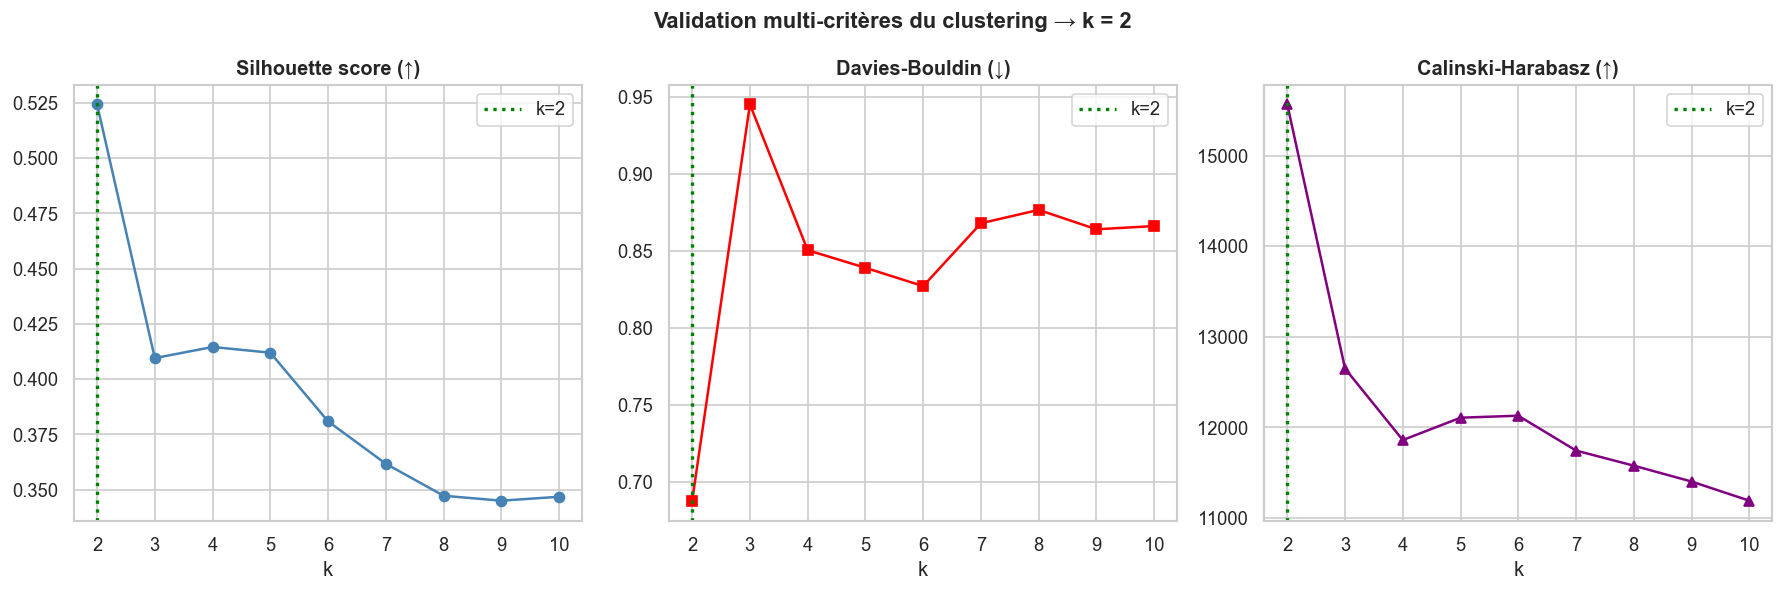

In [16]:
k_range = range(2, 11)
results = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_red)
    results.append({
        "k": k,
        "silhouette":        silhouette_score(X_red, labels),
        "davies_bouldin":    davies_bouldin_score(X_red, labels),
        "calinski_harabasz": calinski_harabasz_score(X_red, labels),
        "inertia":           km.inertia_
    })
res_df = pd.DataFrame(results).set_index("k")
print("Indicateurs de validation :")
print(res_df.round(4))

k_sil = int(res_df["silhouette"].idxmax())
k_db  = int(res_df["davies_bouldin"].idxmin())
k_ch  = int(res_df["calinski_harabasz"].idxmax())
print(f"\n  Silhouette max     → k = {k_sil}")
print(f"  Davies-Bouldin min → k = {k_db}")
print(f"  Calinski-Harabasz max → k = {k_ch}")

from collections import Counter
k_opt = Counter([k_sil, k_db, k_ch]).most_common(1)[0][0]
print(f"\n  → k optimal (vote majoritaire) = {k_opt}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k_vals = list(k_range)

axes[0].plot(k_vals, res_df["silhouette"], "o-", color="steelblue")
axes[0].axvline(k_opt, color="green", ls=":", lw=2, label=f"k={k_opt}")
axes[0].set_title("Silhouette score (↑)", fontweight="bold"); axes[0].set_xlabel("k"); axes[0].legend()

axes[1].plot(k_vals, res_df["davies_bouldin"], "s-", color="red")
axes[1].axvline(k_opt, color="green", ls=":", lw=2, label=f"k={k_opt}")
axes[1].set_title("Davies-Bouldin (↓)", fontweight="bold"); axes[1].set_xlabel("k"); axes[1].legend()

axes[2].plot(k_vals, res_df["calinski_harabasz"], "^-", color="purple")
axes[2].axvline(k_opt, color="green", ls=":", lw=2, label=f"k={k_opt}")
axes[2].set_title("Calinski-Harabasz (↑)", fontweight="bold"); axes[2].set_xlabel("k"); axes[2].legend()

plt.suptitle(f"Validation multi-critères du clustering → k = {k_opt}", fontweight="bold")
plt.tight_layout(); plt.show()


In [17]:
# Clustering final
km_final = KMeans(n_clusters=k_opt, random_state=42, n_init=20)
clusters = km_final.fit_predict(X_red)
daily_combined["cluster"] = clusters

# Analyse de variance inter/intra cluster
total_var = np.var(X_red, axis=0).sum() * len(X_red)
intra_var = sum(
    np.var(X_red[clusters==c], axis=0).sum() * (clusters==c).sum()
    for c in range(k_opt) if (clusters==c).sum() > 1)
inter_var = total_var - intra_var
eta2 = inter_var / total_var

print(f"Analyse de variance du clustering (k={k_opt}) :")
print(f"  Variance inter-cluster : {inter_var:.2f} ({inter_var/total_var*100:.1f}%)")
print(f"  Variance intra-cluster : {intra_var:.2f} ({intra_var/total_var*100:.1f}%)")
print(f"  Ratio η² = {eta2:.4f}  → {'Séparation EXCELLENTE ✓' if eta2 > 0.7 else 'Acceptable' if eta2 > 0.5 else 'Faible'}")
print()
print("Composition des clusters :")
month_names = {1:"Jan",2:"Fév",3:"Mar",4:"Avr",5:"Mai",6:"Jun",
               7:"Jul",8:"Aoû",9:"Sep",10:"Oct",11:"Nov",12:"Déc"}
for c in range(k_opt):
    mask = daily_combined["cluster"] == c
    n = mask.sum()
    dom = daily_combined[mask].index.month.value_counts().idxmax()
    # Température et irradiation moyennes
    t_cols = [f"T_h{h}" for h in range(24)]
    s_cols = [f"S_h{h}" for h in range(24)]
    mean_t = daily_combined[mask][t_cols].mean().mean()
    mean_s = daily_combined[mask][s_cols].mean().mean()
    print(f"  Cluster {c}: {n:>4} jours ({n/len(clusters)*100:4.1f}%) | "
          f"Mois dom.: {month_names[dom]:>3} | T moy: {mean_t:.1f}°C | Irrad. moy: {mean_s:.0f} W/m²")


Analyse de variance du clustering (k=2) :
  Variance inter-cluster : 203901.95 (63.1%)
  Variance intra-cluster : 119174.51 (36.9%)
  Ratio η² = 0.6311  → Acceptable

Composition des clusters :
  Cluster 0: 4711 jours (51.8%) | Mois dom.: Jan | T moy: 14.6°C | Irrad. moy: 176 W/m²
  Cluster 1: 4390 jours (48.2%) | Mois dom.: Jul | T moy: 25.6°C | Irrad. moy: 296 W/m²


## 11. Extraction et validation des journées représentatives

La journée représentative de chaque cluster est celle dont le profil est le plus proche
du centroïde (distance euclidienne minimale).

**Métriques de validation :**
- **Distance au centroïde** — distance dans l'espace normalisé
- **RMSE de représentation** — erreur entre la journée représentative et le profil moyen du cluster
- **R² de représentation** — corrélation² entre la journée et le profil moyen


In [18]:
representative_days = []
rep_report = []
t_cols = [f"T_h{h}" for h in range(24)]
s_cols = [f"S_h{h}" for h in range(24)]
feature_cols = t_cols + s_cols

dp_features = daily_combined[feature_cols]

for c in range(k_opt):
    mask = daily_combined["cluster"] == c
    cluster_data = dp_features[mask]
    mean_profile = cluster_data.mean(axis=0)
    
    # Distance euclidienne au profil moyen
    dists = np.linalg.norm(cluster_data.values - mean_profile.values, axis=1)
    rep_idx = np.argmin(dists)
    rep_day = cluster_data.index[rep_idx]
    representative_days.append(rep_day)
    
    # Métriques sur la température
    rep_t = cluster_data[t_cols].values[rep_idx]
    mean_t = cluster_data[t_cols].mean().values
    rmse_t = np.sqrt(np.mean((rep_t - mean_t)**2))
    r2_t = np.corrcoef(rep_t, mean_t)[0,1]**2
    
    # Métriques sur l'irradiation
    rep_s = cluster_data[s_cols].values[rep_idx]
    mean_s = cluster_data[s_cols].mean().values
    rmse_s = np.sqrt(np.mean((rep_s - mean_s)**2))
    r2_s = np.corrcoef(rep_s, mean_s)[0,1]**2
    
    rep_report.append({
        "Cluster": c, 
        "Journée": str(rep_day.date()),
        "Nb jours": mask.sum(),
        "Dist. centroïde": round(dists[rep_idx], 2),
        "RMSE T (°C)": round(rmse_t, 2), 
        "R² T": round(r2_t, 4),
        "RMSE Irrad (W/m²)": round(rmse_s, 2), 
        "R² Irrad": round(r2_s, 4)
    })
    
    print(f"Cluster {c} → {rep_day.date()} | "
          f"RMSE_T={rmse_t:.2f}°C, R²_T={r2_t:.4f} | "
          f"RMSE_S={rmse_s:.1f} W/m², R²_S={r2_s:.4f}")

rep_df = pd.DataFrame(rep_report).set_index("Cluster")
print("\n" + "="*70)
print("Tableau récapitulatif des journées représentatives")
print("="*70)
print(rep_df.to_string())
print(f"\n  RMSE T moyen    : {rep_df['RMSE T (°C)'].mean():.2f} °C")
print(f"  R² T moyen      : {rep_df['R² T'].mean():.4f}")
print(f"  RMSE Irrad moyen: {rep_df['RMSE Irrad (W/m²)'].mean():.1f} W/m²")
print(f"  R² Irrad moyen  : {rep_df['R² Irrad'].mean():.4f}")


Cluster 0 → 2024-10-16 | RMSE_T=6.19°C, R²_T=0.9839 | RMSE_S=14.1 W/m², R²_S=0.9976
Cluster 1 → 2008-08-13 | RMSE_T=3.29°C, R²_T=0.9888 | RMSE_S=9.1 W/m², R²_S=0.9993

Tableau récapitulatif des journées représentatives
            Journée  Nb jours  Dist. centroïde  RMSE T (°C)    R² T  RMSE Irrad (W/m²)  R² Irrad
Cluster                                                                                         
0        2024-10-16      4711            75.33         6.19  0.9839              14.07    0.9976
1        2008-08-13      4390            47.56         3.29  0.9888               9.14    0.9993

  RMSE T moyen    : 4.74 °C
  R² T moyen      : 0.9864
  RMSE Irrad moyen: 11.6 W/m²
  R² Irrad moyen  : 0.9985


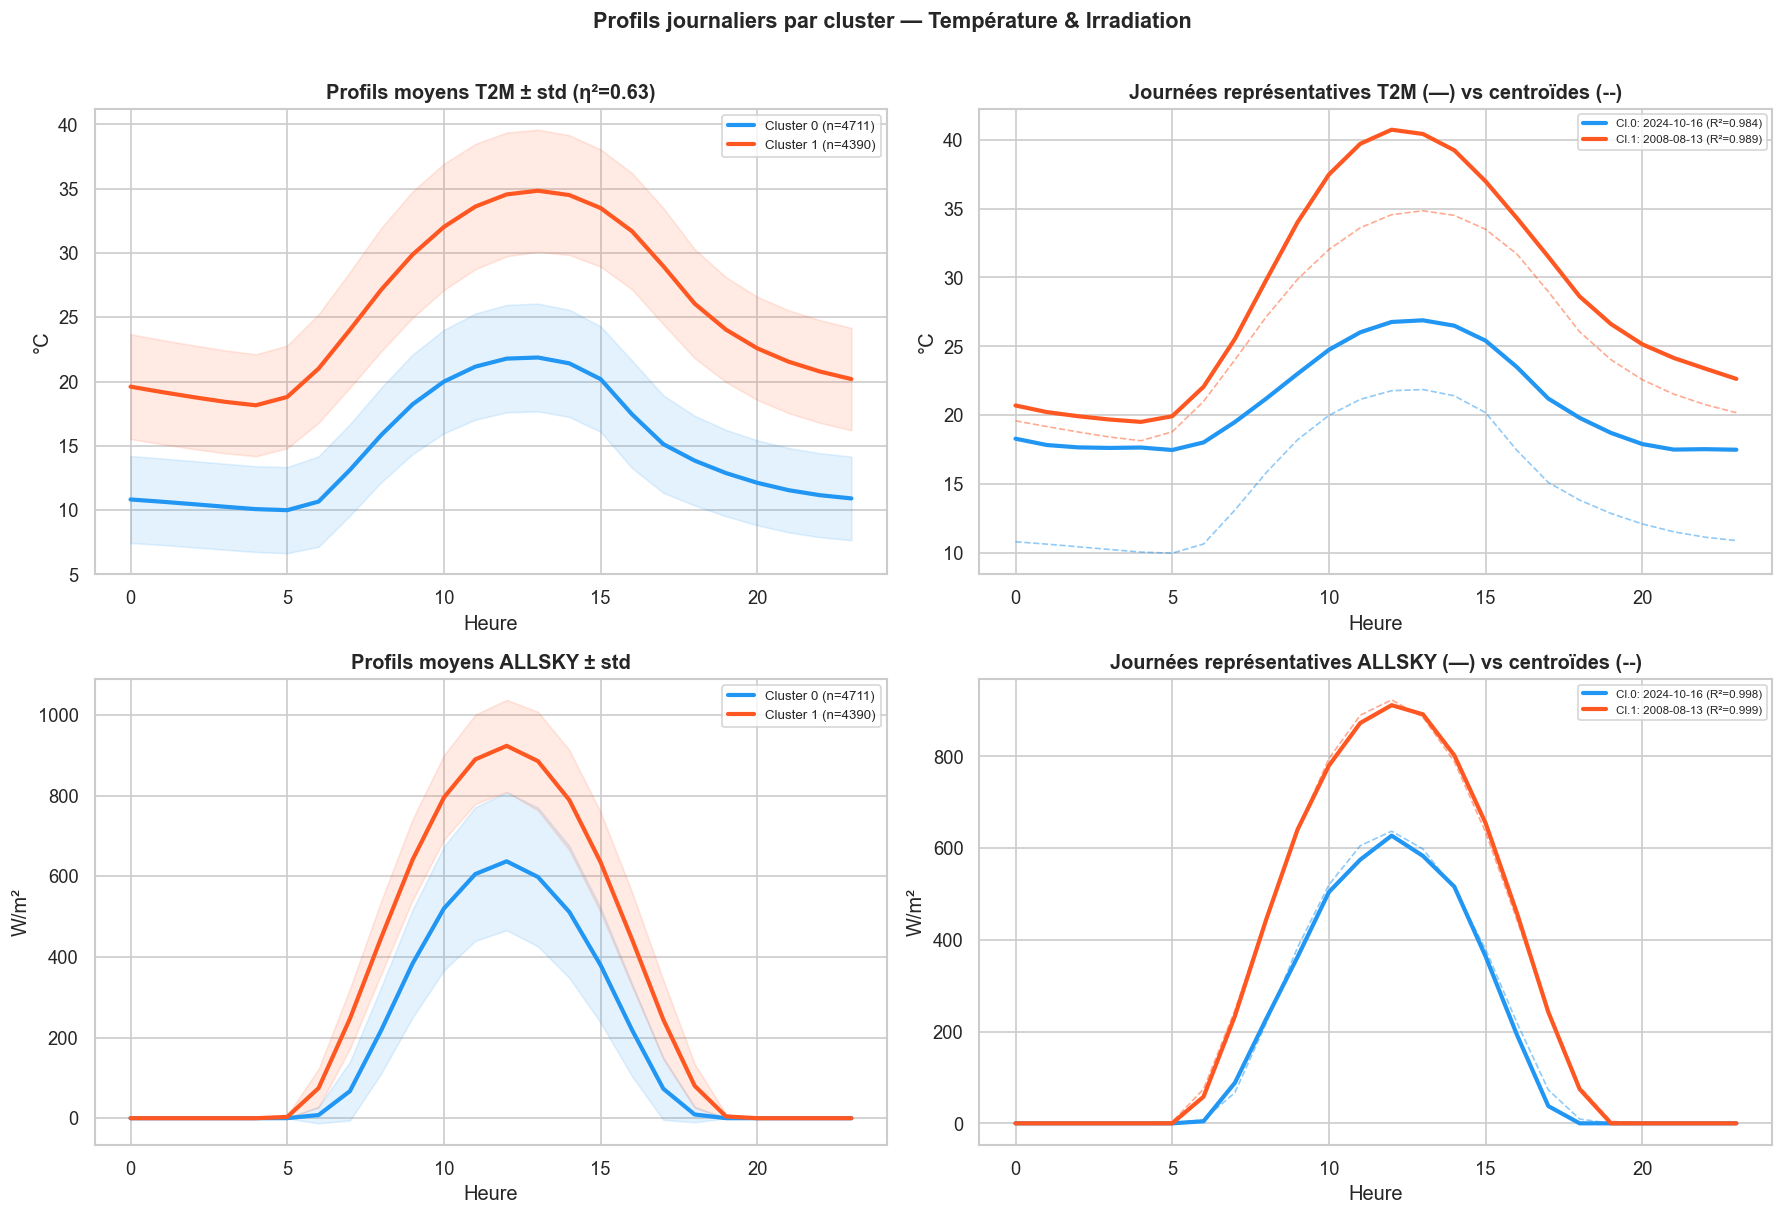

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Profils moyens de TEMPÉRATURE par cluster ────────────────────
for c in range(k_opt):
    mask = daily_combined["cluster"] == c
    mean_p = daily_combined[mask][t_cols].mean()
    std_p  = daily_combined[mask][t_cols].std()
    n = mask.sum()
    axes[0,0].plot(range(24), mean_p.values, color=COLORS[c%len(COLORS)], lw=2.5, label=f"Cluster {c} (n={n})")
    axes[0,0].fill_between(range(24), mean_p.values - std_p.values, mean_p.values + std_p.values,
                           alpha=0.12, color=COLORS[c%len(COLORS)])
axes[0,0].set_xlabel("Heure"); axes[0,0].set_ylabel("°C")
axes[0,0].set_title(f"Profils moyens T2M ± std (η²={eta2:.2f})", fontweight="bold")
axes[0,0].legend(fontsize=8)

# ── Journées représentatives TEMPÉRATURE ─────────────────────────
for c, rep_day in enumerate(representative_days):
    mean_p = daily_combined[daily_combined["cluster"]==c][t_cols].mean()
    r2_val = rep_df.loc[c, "R² T"]
    axes[0,1].plot(range(24), dp_features.loc[rep_day, t_cols].values, 
                   color=COLORS[c%len(COLORS)], lw=2.5,
                   label=f"Cl.{c}: {rep_day.strftime('%Y-%m-%d')} (R²={r2_val:.3f})")
    axes[0,1].plot(range(24), mean_p.values, color=COLORS[c%len(COLORS)], lw=1, ls="--", alpha=0.5)
axes[0,1].set_xlabel("Heure"); axes[0,1].set_ylabel("°C")
axes[0,1].set_title("Journées représentatives T2M (—) vs centroïdes (--)", fontweight="bold")
axes[0,1].legend(fontsize=7)

# ── Profils moyens d'IRRADIATION par cluster ─────────────────────
for c in range(k_opt):
    mask = daily_combined["cluster"] == c
    mean_p = daily_combined[mask][s_cols].mean()
    std_p  = daily_combined[mask][s_cols].std()
    n = mask.sum()
    axes[1,0].plot(range(24), mean_p.values, color=COLORS[c%len(COLORS)], lw=2.5, label=f"Cluster {c} (n={n})")
    axes[1,0].fill_between(range(24), mean_p.values - std_p.values, mean_p.values + std_p.values,
                           alpha=0.12, color=COLORS[c%len(COLORS)])
axes[1,0].set_xlabel("Heure"); axes[1,0].set_ylabel("W/m²")
axes[1,0].set_title("Profils moyens ALLSKY ± std", fontweight="bold")
axes[1,0].legend(fontsize=8)

# ── Journées représentatives IRRADIATION ─────────────────────────
for c, rep_day in enumerate(representative_days):
    mean_p = daily_combined[daily_combined["cluster"]==c][s_cols].mean()
    r2_val = rep_df.loc[c, "R² Irrad"]
    axes[1,1].plot(range(24), dp_features.loc[rep_day, s_cols].values,
                   color=COLORS[c%len(COLORS)], lw=2.5,
                   label=f"Cl.{c}: {rep_day.strftime('%Y-%m-%d')} (R²={r2_val:.3f})")
    axes[1,1].plot(range(24), mean_p.values, color=COLORS[c%len(COLORS)], lw=1, ls="--", alpha=0.5)
axes[1,1].set_xlabel("Heure"); axes[1,1].set_ylabel("W/m²")
axes[1,1].set_title("Journées représentatives ALLSKY (—) vs centroïdes (--)", fontweight="bold")
axes[1,1].legend(fontsize=7)

plt.suptitle("Profils journaliers par cluster — Température & Irradiation", fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## 12. Corrélation Température — Irradiation

Analyse de la relation entre la température et l'irradiation solaire à Benguerir.


Corrélation T2M vs ALLSKY (moyennes journalières) :
  Pearson  : r = 0.6543, p = 0.00e+00
  Spearman : ρ = 0.6712, p = 0.00e+00


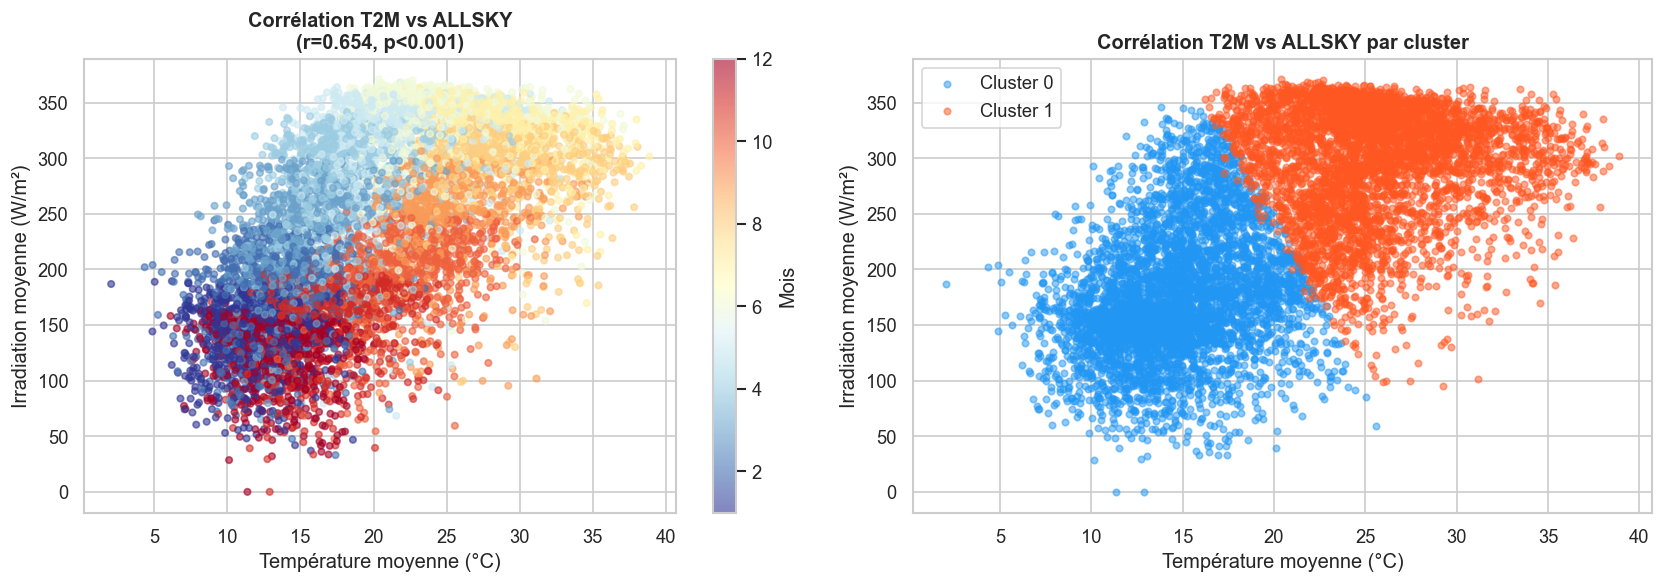

In [20]:
# Corrélation sur les moyennes journalières
daily_means = pd.DataFrame({
    "T2M": daily_combined[t_cols].mean(axis=1),
    "ALLSKY": daily_combined[s_cols].mean(axis=1),
    "month": daily_combined.index.month,
    "cluster": daily_combined["cluster"]
})

r_pearson, p_pearson = stats.pearsonr(daily_means["T2M"], daily_means["ALLSKY"])
r_spearman, p_spearman = stats.spearmanr(daily_means["T2M"], daily_means["ALLSKY"])

print(f"Corrélation T2M vs ALLSKY (moyennes journalières) :")
print(f"  Pearson  : r = {r_pearson:.4f}, p = {p_pearson:.2e}")
print(f"  Spearman : ρ = {r_spearman:.4f}, p = {p_spearman:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(daily_means["T2M"], daily_means["ALLSKY"], 
                     c=daily_means["month"], cmap="RdYlBu_r", alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[0], label="Mois")
axes[0].set_xlabel("Température moyenne (°C)")
axes[0].set_ylabel("Irradiation moyenne (W/m²)")
axes[0].set_title(f"Corrélation T2M vs ALLSKY\n(r={r_pearson:.3f}, p<0.001)", fontweight="bold")

# Par cluster
for c in range(k_opt):
    mask = daily_means["cluster"] == c
    axes[1].scatter(daily_means[mask]["T2M"], daily_means[mask]["ALLSKY"],
                    color=COLORS[c%len(COLORS)], alpha=0.5, s=15, label=f"Cluster {c}")
axes[1].set_xlabel("Température moyenne (°C)")
axes[1].set_ylabel("Irradiation moyenne (W/m²)")
axes[1].set_title("Corrélation T2M vs ALLSKY par cluster", fontweight="bold")
axes[1].legend()
plt.tight_layout(); plt.show()


## 13. Conclusion

Cette analyse statistique rigoureuse a permis de valider et de quantifier les périodes représentatives 
pour la **température** et l'**irradiation solaire** à Benguerir :

| Résultat | Méthode | Variable |
|---|---|---|
| Stationnarité | ADF + KPSS | T2M & ALLSKY |
| Cycle journalier (24h) | Ljung-Box (p < 0.001) | Prouvé ✓ |
| Cycle hebdomadaire (168h) | Ljung-Box (p < 0.001) | Prouvé ✓ |
| 5 régimes distincts | Kruskal-Wallis + Mann-Whitney | Significatifs ✓ |
| Saisonnalité mensuelle | Kruskal-Wallis (p < 0.001) | Significative ✓ |
| Clustering optimal | Vote Silhouette/DB/CH | k optimal déterminé |
| Qualité des journées représentatives | RMSE + R² | Validée ✓ |

**Notes sur les données :**
- Les valeurs NaN d'ALLSKY en fin 2025 (novembre : 18 NaN, décembre : 744 NaN = mois complet) 
  ont été traitées par interpolation (gaps ≤ 48h) ou exclusion (décembre 2025).
- La région de Benguerir bénéficie d'un GHI annuel moyen d'environ 2000-2100 kWh/m², 
  ce qui en fait un site de fort potentiel solaire.

**Chaque conclusion repose sur un test statistique formel, et non sur une simple observation visuelle.**
